# NCA Parent ML — Annual z-score IA45 + POLARIS comparison

This notebook performs a controlled three-way comparison of the current
8-parent vegetation classifier:

\[
\textbf{Z only}
\]

\[
\textbf{POLARIS only}
\]

\[
\textbf{Z + POLARIS}
\]

where **Z** is the annual-relative IA45 representation already tested in
`NCA_ParentML_IA45_AnnualZScore.ipynb`.

The experiment intentionally preserves the existing supervised architecture:

- same vegetation labels;
- same grouped `PlotID` cross-validation;
- same leave-one-year-out validation;
- same elastic-net logistic / random forest / Extra Trees learners;
- same annual z-score transformation;
- same blockwise mapping logic;
- same max-probability / probability-margin / entropy uncertainty outputs;
- same 8 vegetation-parent response classes.

The only required path edit is the POLARIS TIFF in the first code cell.
The following code cell is an **optional predictor-selection cell** so that
soil-variable families can be added or removed without changing the rest of
the notebook.

The starting POLARIS experiment uses **sand, silt, and clay across all six
depth intervals**.


In [13]:
# =============================================================================
# 0. CONFIGURATION
#
# REQUIRED USER EDIT:
#     Change POLARIS_TIF to the local POLARIS multiband TIFF.
#
# Everything else is already pointed at the current NCA workflow.
# =============================================================================

from pathlib import Path
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch
from IPython.display import display

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 280)


# -----------------------------------------------------------------------------
# CHANGE THIS PATH
# -----------------------------------------------------------------------------

POLARIS_TIF = Path(
    r"C:\NCA_DATA\Ancillary_Data\POLARIS\POLARIS_vrt\POLARIS_26911_10m_mosaic_exact.tif"
)


# -----------------------------------------------------------------------------
# CURRENT NCA WORKFLOW PATHS
# -----------------------------------------------------------------------------

OPTICAL_SAMPLE_DIR = Path(
    r"C:\NCA_DATA\Analysis\Static_Optical_Sample_IA45"
)

ZSCORE_OUTPUT_DIR = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45"
)

ZSCORE_PARAMETER_CSV = (
    ZSCORE_OUTPUT_DIR
    / "annual_IA45_zscore_parameters_S500.csv"
)

VEG_TRAINING_CSV = Path(
    r"A:\NCA_DATA\Validation\Supervised_State_Classification"
    r"\FieldVeg_K2_IA45_Training.csv"
)

HARMONIC_ROOT = Path(
    r"A:\NCA_DATA\S2_Harmonics"
)

KEEP_MASK = Path(
    r"C:\NCA_DATA\templates\Masks\NCA_keepMask_v2.tif"
)

OUTPUT_DIR = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POLARIS"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# -----------------------------------------------------------------------------
# ANALYSIS SETTINGS
# -----------------------------------------------------------------------------

YEARS_TO_MAP = list(
    range(
        2016,
        2026,
    )
)

VEG_YEARS = [
    2016,
    2018,
    2025,
]

REFERENCE_TIER = 500
EXPECTED_IA_D = 45

VEG_PARENT_CODES = list(
    range(
        1,
        9,
    )
)

VEG_CLASSES = [
    f"VEG::{i}"
    for i in VEG_PARENT_CODES
]

CLASS_TO_CODE = {
    f"VEG::{i}": i
    for i in VEG_PARENT_CODES
}

CODE_TO_CLASS = {
    code: cls
    for cls, code in CLASS_TO_CODE.items()
}

RANDOM_STATE = 42
N_SPLITS = 5
COMPRESS = "DEFLATE"

MODEL_FOR_MAPPING = "random_forest"

# Keep False for the controlled comparison to the current z-score baseline.
FILTER_TRAINING_TO_MASK = False

# Continuous POLARIS surfaces. If the raster is already aligned to the
# Sentinel grid, no resampling occurs.
POLARIS_RESAMPLING = Resampling.bilinear

RUN_MAPPING = True
SAVE_COMPARISON_FIGURES = True

print("POLARIS:", POLARIS_TIF)
print("Output:", OUTPUT_DIR)


POLARIS: C:\NCA_DATA\Ancillary_Data\POLARIS\POLARIS_vrt\POLARIS_26911_10m_mosaic_exact.tif
Output: C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POLARIS


## POLARIS predictor selection

The current POLARIS stack contains **42 bands**:

**Variables**
- `sand` — percent sand
- `silt` — percent silt
- `clay` — percent clay
- `bd` — bulk density
- `theta_s` — saturated soil-water content
- `ph` — soil pH
- `om_log10` — organic matter in log10 space

**Depths**
- `0_5`
- `5_15`
- `15_30`
- `30_60`
- `60_100`
- `100_200`

The canonical band order is variable-major, then depth:

`{variable}_{depth}`.

The starting experiment deliberately uses raw `% sand`, `% silt`, and `% clay`
at all six depths. Texture is compositional, so a later sensitivity analysis
should compare this benchmark with an ILR representation; this notebook does
**not** silently change the texture geometry.


In [14]:
# =============================================================================
# 0B. POLARIS VARIABLE SELECTION
#
# OPTIONAL USER EDIT:
#     Change these lists to test other POLARIS predictor families.
#
# The default is sand + silt + clay across all six depths.
# =============================================================================

POLARIS_VARIABLES = [
    "sand",
    "silt",
    "clay",
]

POLARIS_DEPTHS = [
    "0_5",
    "5_15",
    "15_30",
    "30_60",
    "60_100",
    "100_200",
]


POLARIS_VARIABLE_INFO = {
    "sand": "percent sand",
    "silt": "percent silt",
    "clay": "percent clay",
    "bd": "bulk density",
    "theta_s": "saturated soil-water content",
    "ph": "soil pH",
    "om_log10": "organic matter (log10)",
}


CANONICAL_POLARIS_VARIABLE_ORDER = [
    "sand",
    "silt",
    "clay",
    "bd",
    "theta_s",
    "ph",
    "om_log10",
]

CANONICAL_POLARIS_DEPTH_ORDER = [
    "0_5",
    "5_15",
    "15_30",
    "30_60",
    "60_100",
    "100_200",
]


CANONICAL_POLARIS_BANDS = [
    f"{variable}_{depth}"
    for variable in CANONICAL_POLARIS_VARIABLE_ORDER
    for depth in CANONICAL_POLARIS_DEPTH_ORDER
]


SELECTED_POLARIS_BANDS = [
    f"{variable}_{depth}"
    for variable in POLARIS_VARIABLES
    for depth in POLARIS_DEPTHS
]


unknown_variables = sorted(
    set(
        POLARIS_VARIABLES
    )
    - set(
        CANONICAL_POLARIS_VARIABLE_ORDER
    )
)

unknown_depths = sorted(
    set(
        POLARIS_DEPTHS
    )
    - set(
        CANONICAL_POLARIS_DEPTH_ORDER
    )
)

if unknown_variables:
    raise ValueError(
        f"Unknown POLARIS variables: {unknown_variables}"
    )

if unknown_depths:
    raise ValueError(
        f"Unknown POLARIS depths: {unknown_depths}"
    )


print("Selected POLARIS variables:")

for variable in POLARIS_VARIABLES:
    print(
        f"  {variable:10s} — "
        f"{POLARIS_VARIABLE_INFO[variable]}"
    )

print(
    "\nSelected depths:",
    POLARIS_DEPTHS,
)

print(
    "\nSelected POLARIS predictor count:",
    len(
        SELECTED_POLARIS_BANDS
    ),
)

print(
    "\nSelected bands:"
)

for band in SELECTED_POLARIS_BANDS:
    print(
        " ",
        band,
    )


Selected POLARIS variables:
  sand       — percent sand
  silt       — percent silt
  clay       — percent clay

Selected depths: ['0_5', '5_15', '15_30', '30_60', '60_100', '100_200']

Selected POLARIS predictor count: 18

Selected bands:
  sand_0_5
  sand_5_15
  sand_15_30
  sand_30_60
  sand_60_100
  sand_100_200
  silt_0_5
  silt_5_15
  silt_15_30
  silt_30_60
  silt_60_100
  silt_100_200
  clay_0_5
  clay_5_15
  clay_15_30
  clay_30_60
  clay_60_100
  clay_100_200


## 1. Resolve IA45 feature names and annual z-score parameters

The notebook first reuses the S500 annual normalization parameters already
written by the z-score workflow. If that file is missing, it reconstructs the
same weighted S500 parameters from the static optical sample.


In [15]:
# =============================================================================
# 1. IA45 NAMES
# =============================================================================

ANNUAL_METADATA_COLS = {
    "point_id",
    "Year",
    "tile_id",
    "sample_rank",
    "mask_row",
    "mask_col",
    "Easting",
    "Northing",
    "in_s100",
    "in_s250",
    "in_s500",
    "valid_ia45",
}


def annual_sample_path(
    year,
):
    return (
        OPTICAL_SAMPLE_DIR
        / f"static_optical_IA45_{year}.csv.gz"
    )


def annual_k2_path(
    year,
):
    return (
        HARMONIC_ROOT
        / str(
            year
        )
        / (
            f"{year}"
            "_K2_InterceptAmpPhase_nobs_RMSE.tif"
        )
    )


first_annual = annual_sample_path(
    YEARS_TO_MAP[0]
)

if not first_annual.exists():
    raise FileNotFoundError(
        f"Missing annual optical sample:\n{first_annual}"
    )

header = pd.read_csv(
    first_annual,
    compression="gzip",
    nrows=0,
)

IA_COLS = [
    c
    for c in header.columns
    if c not in ANNUAL_METADATA_COLS
]

if len(
    IA_COLS
) != EXPECTED_IA_D:
    raise ValueError(
        f"Expected {EXPECTED_IA_D} IA45 features; "
        f"found {len(IA_COLS)}."
    )

print(
    "IA45 feature count:",
    len(
        IA_COLS
    )
)


IA45 feature count: 45


In [16]:
# =============================================================================
# 1B. LOAD OR RECONSTRUCT S500 Z-SCORE PARAMETERS
# =============================================================================

def weighted_mean_sd(
    x,
    w,
):
    x = np.asarray(
        x,
        dtype=np.float64,
    )

    w = np.asarray(
        w,
        dtype=np.float64,
    )

    valid = (
        np.isfinite(
            x
        )
        & np.isfinite(
            w
        )
        & (
            w > 0
        )
    )

    x = x[
        valid
    ]

    w = w[
        valid
    ]

    weight_sum = np.sum(
        w
    )

    mean = np.sum(
        w
        * x
    ) / weight_sum

    variance = np.sum(
        w
        * (
            x
            - mean
        ) ** 2
    ) / weight_sum

    return (
        float(
            mean
        ),
        float(
            np.sqrt(
                variance
            )
        ),
    )


if ZSCORE_PARAMETER_CSV.exists():

    reference_parameters = pd.read_csv(
        ZSCORE_PARAMETER_CSV
    )

    print(
        "Loaded existing S500 z-score parameters:"
    )

    print(
        ZSCORE_PARAMETER_CSV
    )

else:

    print(
        "Existing S500 parameter file not found."
    )

    print(
        "Reconstructing S500 parameters from the static optical sample."
    )

    TILE_MANIFEST = (
        OPTICAL_SAMPLE_DIR
        / "static_optical_tile_manifest.csv"
    )

    TEMPORAL_COVERAGE = (
        OPTICAL_SAMPLE_DIR
        / "static_optical_sample_temporal_coverage.csv"
    )

    tiles = pd.read_csv(
        TILE_MANIFEST
    )

    sample_support = pd.read_csv(
        TEMPORAL_COVERAGE
    )

    sample_support[
        "persistent_valid"
    ] = (
        sample_support[
            "persistent_valid"
        ]
        .astype(str)
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
            }
        )
    )

    reference_points = (
        sample_support.loc[
            sample_support[
                "persistent_valid"
            ]
            & sample_support[
                "sample_rank"
            ].le(
                REFERENCE_TIER
            ),
            [
                "point_id",
                "tile_id",
            ],
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    tile_valid_lookup = (
        tiles[
            [
                "tile_id",
                "n_valid_pixels",
            ]
        ]
        .drop_duplicates()
        .set_index(
            "tile_id"
        )[
            "n_valid_pixels"
        ]
        .to_dict()
    )

    per_tile_n = (
        reference_points[
            "tile_id"
        ]
        .value_counts()
        .to_dict()
    )

    reference_points[
        "tile_valid_pixels"
    ] = reference_points[
        "tile_id"
    ].map(
        tile_valid_lookup
    )

    reference_points[
        "n_sample_in_tile"
    ] = reference_points[
        "tile_id"
    ].map(
        per_tile_n
    )

    reference_points[
        "population_weight"
    ] = (
        reference_points[
            "tile_valid_pixels"
        ]
        / reference_points[
            "n_sample_in_tile"
        ]
    )

    parameter_rows = []

    for year in YEARS_TO_MAP:

        annual = pd.read_csv(
            annual_sample_path(
                year
            ),
            compression="gzip",
            usecols=(
                [
                    "point_id",
                    "valid_ia45",
                ]
                + IA_COLS
            ),
        )

        annual[
            "valid_ia45"
        ] = (
            annual[
                "valid_ia45"
            ]
            .astype(str)
            .str.lower()
            .map(
                {
                    "true": True,
                    "false": False,
                }
            )
        )

        merged = reference_points.merge(
            annual,
            on="point_id",
            how="left",
            validate="one_to_one",
        )

        if not merged[
            "valid_ia45"
        ].all():
            raise RuntimeError(
                f"Persistent-valid S500 support failed in {year}."
            )

        weights = merged[
            "population_weight"
        ].to_numpy(
            dtype=np.float64
        )

        for feature in IA_COLS:

            mu, sd = weighted_mean_sd(
                merged[
                    feature
                ].to_numpy(
                    dtype=np.float64
                ),
                weights,
            )

            parameter_rows.append(
                {
                    "sample_tier": "S500",
                    "tier_n": 500,
                    "Year": year,
                    "feature": feature,
                    "weighted_mean": mu,
                    "weighted_sd": sd,
                }
            )

    reference_parameters = pd.DataFrame(
        parameter_rows
    )

    reference_parameters.to_csv(
        OUTPUT_DIR
        / "annual_IA45_zscore_parameters_S500_reconstructed.csv",
        index=False,
    )


expected_parameter_rows = (
    len(
        YEARS_TO_MAP
    )
    * EXPECTED_IA_D
)

if len(
    reference_parameters
) != expected_parameter_rows:
    raise RuntimeError(
        f"Expected {expected_parameter_rows} z-score parameter rows; "
        f"found {len(reference_parameters)}."
    )


reference_lookup = {}

for year in YEARS_TO_MAP:

    year_params = (
        reference_parameters.loc[
            reference_parameters[
                "Year"
            ].eq(
                year
            )
        ]
        .set_index(
            "feature"
        )
    )

    reference_lookup[
        year
    ] = {
        "mean": np.array(
            [
                year_params.loc[
                    feature,
                    "weighted_mean",
                ]
                for feature in IA_COLS
            ],
            dtype=np.float64,
        ),
        "sd": np.array(
            [
                year_params.loc[
                    feature,
                    "weighted_sd",
                ]
                for feature in IA_COLS
            ],
            dtype=np.float64,
        ),
    }

print(
    "Annual z-score parameters ready."
)


Loaded existing S500 z-score parameters:
C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45\annual_IA45_zscore_parameters_S500.csv
Annual z-score parameters ready.


## 2. Resolve the POLARIS stack

The notebook first uses raster band descriptions if they match the canonical
POLARIS names. If descriptions are absent/generic and the TIFF has exactly
42 bands, it falls back to the known canonical 42-band order automatically.

Therefore the normal workflow requires **no manual band-number editing**.


In [17]:
# =============================================================================
# 2. POLARIS BAND QA / RESOLUTION
# =============================================================================

if not POLARIS_TIF.exists():
    raise FileNotFoundError(
        f"POLARIS TIFF not found:\n{POLARIS_TIF}"
    )


def normalize_name(
    x,
):
    return (
        str(
            x
        )
        .strip()
        .lower()
        .replace(
            "-",
            "_",
        )
        .replace(
            " ",
            "_",
        )
    )


with rasterio.open(
    POLARIS_TIF
) as src:

    polaris_count = src.count
    polaris_crs = src.crs
    polaris_transform = src.transform
    polaris_shape = (
        src.height,
        src.width,
    )
    raw_descriptions = list(
        src.descriptions
    )


description_names = [
    normalize_name(
        x
    )
    if x is not None
    else ""
    for x in raw_descriptions
]


canonical_lookup = {
    normalize_name(
        name
    ): i
    for i, name in enumerate(
        CANONICAL_POLARIS_BANDS,
        start=1,
    )
}


descriptions_are_complete = (
    len(
        description_names
    )
    == len(
        CANONICAL_POLARIS_BANDS
    )
    and set(
        description_names
    )
    == set(
        canonical_lookup.keys()
    )
)


if descriptions_are_complete:

    POLARIS_BAND_INDEX = {
        name: (
            description_names.index(
                normalize_name(
                    name
                )
            )
            + 1
        )
        for name in CANONICAL_POLARIS_BANDS
    }

    band_resolution_method = (
        "Raster descriptions matched canonical names."
    )

elif polaris_count == len(
    CANONICAL_POLARIS_BANDS
):

    POLARIS_BAND_INDEX = {
        name: i
        for i, name in enumerate(
            CANONICAL_POLARIS_BANDS,
            start=1,
        )
    }

    band_resolution_method = (
        "Raster descriptions were absent/generic; "
        "used canonical 42-band stack order."
    )

else:

    raise ValueError(
        "POLARIS stack could not be resolved automatically.\n"
        f"Raster has {polaris_count} bands; expected 42.\n"
        f"Descriptions: {raw_descriptions}"
    )


SELECTED_POLARIS_INDEXES = [
    POLARIS_BAND_INDEX[
        band
    ]
    for band in SELECTED_POLARIS_BANDS
]


print(
    band_resolution_method
)

print(
    "POLARIS CRS:",
    polaris_crs,
)

print(
    "POLARIS shape:",
    polaris_shape,
)

print(
    "Selected band indexes:",
    SELECTED_POLARIS_INDEXES,
)


band_qa = pd.DataFrame(
    {
        "band_name": SELECTED_POLARIS_BANDS,
        "band_index": SELECTED_POLARIS_INDEXES,
        "variable": [
            band.rsplit(
                "_",
                2,
            )[0]
            if not band.startswith(
                "om_log10"
            )
            else "om_log10"
            for band in SELECTED_POLARIS_BANDS
        ],
    }
)

display(
    band_qa
)

band_qa.to_csv(
    OUTPUT_DIR
    / "POLARIS_selected_band_QA.csv",
    index=False,
)


Raster descriptions were absent/generic; used canonical 42-band stack order.
POLARIS CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North American Datum 1983",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
POLARIS shape: (7857, 10435)
Selected band indexes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


,band_name,band_index,variable
0,sand_0_5,1,sand
1,sand_5_15,2,sand
2,sand_15_30,3,sand
3,sand_30_60,4,sand
4,sand_60_100,5,sand
5,sand_100_200,6,sand
6,silt_0_5,7,silt
7,silt_5_15,8,silt
8,silt_15_30,9,silt
9,silt_30_60,10,silt


## 3. Load vegetation training observations and align IA45 features

For a fair representation comparison, the final analysis dataset uses the
**same complete-case rows for all three feature sets**. If a vegetation point
does not have valid selected POLARIS values, that row is removed from Z-only,
POLARIS-only, and Z+POLARIS alike.


In [18]:
# =============================================================================
# 3. LOAD VEGETATION TRAINING TABLE
# =============================================================================

veg = pd.read_csv(
    VEG_TRAINING_CSV,
    low_memory=False,
).drop(
    columns=[
        "Unnamed: 0",
    ],
    errors="ignore",
)

veg[
    "Year"
] = pd.to_numeric(
    veg[
        "Year"
    ],
    errors="coerce",
)

veg[
    "parent_cluster"
] = pd.to_numeric(
    veg[
        "parent_cluster"
    ],
    errors="coerce",
)

veg = (
    veg.loc[
        veg[
            "Year"
        ].isin(
            VEG_YEARS
        )
        & veg[
            "parent_cluster"
        ].isin(
            VEG_PARENT_CODES
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

veg[
    "Year"
] = veg[
    "Year"
].astype(
    int
)

veg[
    "parent_cluster"
] = veg[
    "parent_cluster"
].astype(
    int
)

veg[
    "PlotID"
] = (
    veg[
        "PlotID"
    ]
    .astype(str)
    .str.strip()
)


def normalize_feature_name(
    x,
):
    return (
        str(
            x
        )
        .strip()
        .lower()
    )


veg_candidate_cols = []

for col in veg.columns:

    lower = normalize_feature_name(
        col
    )

    is_intercept = (
        re.search(
            r"(^|_)(intercept|constant)($|_)",
            lower,
        )
        is not None
    )

    is_amplitude = (
        re.search(
            r"(^|_)(amp|amplitude)",
            lower,
        )
        is not None
    )

    if (
        is_intercept
        or is_amplitude
    ):
        veg_candidate_cols.append(
            col
        )


if len(
    veg_candidate_cols
) != EXPECTED_IA_D:
    raise ValueError(
        f"Expected {EXPECTED_IA_D} IA45 columns in vegetation table; "
        f"found {len(veg_candidate_cols)}."
    )


sample_lookup = {
    normalize_feature_name(
        c
    ): c
    for c in IA_COLS
}

veg_to_sample = {}

for veg_col in veg_candidate_cols:

    key = normalize_feature_name(
        veg_col
    )

    if key not in sample_lookup:
        raise KeyError(
            f"Vegetation IA45 feature does not match optical sample: {veg_col}"
        )

    veg_to_sample[
        veg_col
    ] = sample_lookup[
        key
    ]


sample_to_veg = {
    sample_name: veg_name
    for veg_name, sample_name in veg_to_sample.items()
}

VEG_IA_COLS = [
    sample_to_veg[
        feature
    ]
    for feature in IA_COLS
]


required_xy = [
    "Easting",
    "Northing",
]

if not all(
    c in veg.columns
    for c in required_xy
):
    raise KeyError(
        "Vegetation table must contain Easting and Northing."
    )

print(
    "Vegetation rows before POLARIS complete-case filtering:",
    len(
        veg
    )
)


Vegetation rows before POLARIS complete-case filtering: 479


## 4. Extract selected POLARIS predictors at vegetation plots

POLARIS is read on the Sentinel grid through a `WarpedVRT` when needed.
The selected soil values are static: the same location receives the same soil
vector regardless of vegetation-observation year.


In [19]:
# =============================================================================
# 4. EXTRACT POLARIS AT VEGETATION POINTS
# =============================================================================

reference_raster_path = annual_k2_path(
    YEARS_TO_MAP[0]
)

with rasterio.open(
    reference_raster_path
) as ref:

    ref_crs = ref.crs
    ref_transform = ref.transform
    ref_width = ref.width
    ref_height = ref.height


def grids_match_definition(
    src,
    crs,
    transform,
    width,
    height,
):
    return (
        src.crs == crs
        and src.transform == transform
        and src.width == width
        and src.height == height
    )


coords = list(
    zip(
        veg[
            "Easting"
        ].astype(
            float
        ),
        veg[
            "Northing"
        ].astype(
            float
        ),
    )
)


with rasterio.open(
    POLARIS_TIF
) as polaris_src:

    if grids_match_definition(
        polaris_src,
        ref_crs,
        ref_transform,
        ref_width,
        ref_height,
    ):

        polaris_reader = polaris_src
        polaris_vrt = None

    else:

        polaris_vrt = WarpedVRT(
            polaris_src,
            crs=ref_crs,
            transform=ref_transform,
            width=ref_width,
            height=ref_height,
            resampling=POLARIS_RESAMPLING,
        )

        polaris_reader = polaris_vrt


    sampled_rows = []

    for sample in polaris_reader.sample(
        coords,
        indexes=SELECTED_POLARIS_INDEXES,
        masked=True,
    ):

        sampled_rows.append(
            np.asarray(
                sample.filled(
                    np.nan
                ),
                dtype=np.float64,
            )
        )


    if polaris_vrt is not None:
        polaris_vrt.close()


X_polaris_all = np.vstack(
    sampled_rows
)


for j, band in enumerate(
    SELECTED_POLARIS_BANDS
):

    veg[
        f"POLARIS__{band}"
    ] = X_polaris_all[
        :,
        j
    ]


valid_polaris = np.isfinite(
    X_polaris_all
).all(
    axis=1
)


print(
    "Rows with complete selected POLARIS predictors:",
    f"{valid_polaris.sum():,} / {len(veg):,}"
)


# Optional mask filter retained from prior notebooks.
if FILTER_TRAINING_TO_MASK:

    def keep_mask_at_points(
        table,
    ):

        with rasterio.open(
            KEEP_MASK
        ) as src:

            sampled = list(
                src.sample(
                    list(
                        zip(
                            table[
                                "Easting"
                            ].astype(
                                float
                            ),
                            table[
                                "Northing"
                            ].astype(
                                float
                            ),
                        )
                    ),
                    indexes=1,
                    masked=True,
                )
            )

        keep = np.array(
            [
                (
                    not s.mask[
                        0
                    ]
                    and np.isfinite(
                        s[
                            0
                        ]
                    )
                    and s[
                        0
                    ] > 0
                )
                for s in sampled
            ],
            dtype=bool,
        )

        return keep


    valid_mask = keep_mask_at_points(
        veg
    )

else:

    valid_mask = np.ones(
        len(
            veg
        ),
        dtype=bool,
    )


analysis_keep = (
    valid_polaris
    & valid_mask
)


veg = (
    veg.loc[
        analysis_keep
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

X_polaris = (
    veg[
        [
            f"POLARIS__{band}"
            for band in SELECTED_POLARIS_BANDS
        ]
    ]
    .to_numpy(
        dtype=np.float64
    )
)


print(
    "Final common analysis rows:",
    len(
        veg
    )
)

display(
    veg[
        [
            "PlotID",
            "Year",
            "parent_cluster",
        ]
        + [
            f"POLARIS__{band}"
            for band in SELECTED_POLARIS_BANDS[
                :6
            ]
        ]
    ].head()
)


Rows with complete selected POLARIS predictors: 479 / 479
Final common analysis rows: 479


,PlotID,Year,parent_cluster,POLARIS__sand_0_5,POLARIS__sand_5_15,POLARIS__sand_15_30,POLARIS__sand_30_60,POLARIS__sand_60_100,POLARIS__sand_100_200
0,100,2016,3,23.906250,23.094543,20.790449,18.494152,27.476606,54.610352
1,101,2016,3,23.900391,23.058048,20.751707,18.494152,27.333332,54.602440
2,102,2016,4,45.500000,45.500000,47.500000,62.500000,77.500000,77.500000
3,103,2016,1,45.500000,45.500000,47.500000,62.500000,77.500000,77.500000
4,104,2016,1,45.500000,45.500000,47.500000,62.500000,77.500000,77.500000


## 5. Build the three feature representations

The same final rows, labels, groups, and CV folds are used for:

- `z`
- `polaris`
- `z_plus_polaris`

This isolates the information contribution of the static soil domain.


In [20]:
# =============================================================================
# 5. BUILD FEATURE MATRICES
# =============================================================================

X_raw_ia = (
    veg[
        VEG_IA_COLS
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .to_numpy(
        dtype=np.float64
    )
)

if not np.isfinite(
    X_raw_ia
).all():
    raise ValueError(
        "Invalid IA45 values remain in the common analysis dataset."
    )


years_veg = veg[
    "Year"
].to_numpy(
    dtype=int
)

X_z = np.full_like(
    X_raw_ia,
    np.nan,
    dtype=np.float64,
)


for year in np.unique(
    years_veg
):

    mask = (
        years_veg
        == year
    )

    params = reference_lookup[
        int(
            year
        )
    ]

    X_z[
        mask
    ] = (
        X_raw_ia[
            mask
        ]
        - params[
            "mean"
        ]
    ) / params[
        "sd"
    ]


if not np.isfinite(
    X_z
).all():
    raise ValueError(
        "Annual z-score transformation produced invalid values."
    )


X_z_plus_polaris = np.hstack(
    [
        X_z,
        X_polaris,
    ]
)


REPRESENTATIONS = {
    "z": X_z,
    "polaris": X_polaris,
    "z_plus_polaris": X_z_plus_polaris,
}


REPRESENTATION_FEATURE_NAMES = {
    "z": [
        f"z__{feature}"
        for feature in IA_COLS
    ],
    "polaris": [
        f"POLARIS__{band}"
        for band in SELECTED_POLARIS_BANDS
    ],
    "z_plus_polaris": (
        [
            f"z__{feature}"
            for feature in IA_COLS
        ]
        + [
            f"POLARIS__{band}"
            for band in SELECTED_POLARIS_BANDS
        ]
    ),
}


representation_qa = pd.DataFrame(
    [
        {
            "representation": name,
            "n_rows": X.shape[
                0
            ],
            "n_features": X.shape[
                1
            ],
        }
        for name, X in REPRESENTATIONS.items()
    ]
)

display(
    representation_qa
)


# Save the explicit common ML dataset.
ml_dataset = veg[
    [
        "PlotID",
        "Year",
        "parent_cluster",
        "Easting",
        "Northing",
    ]
].copy()

for j, feature in enumerate(
    REPRESENTATION_FEATURE_NAMES[
        "z"
    ]
):
    ml_dataset[
        feature
    ] = X_z[
        :,
        j
    ]

for j, feature in enumerate(
    REPRESENTATION_FEATURE_NAMES[
        "polaris"
    ]
):
    ml_dataset[
        feature
    ] = X_polaris[
        :,
        j
    ]

ml_dataset.to_csv(
    OUTPUT_DIR
    / "FieldVeg_AnnualZScore_POLARIS_common_ML_dataset.csv",
    index=False,
)


,representation,n_rows,n_features
0,z,479,45
1,polaris,479,18
2,z_plus_polaris,479,63


## 6. Models and fixed grouped folds

The fold assignment is generated once and reused across all three
representations.


In [21]:
# =============================================================================
# 6. MODELS
# =============================================================================

MODELS = {
    "elastic_net_logistic": Pipeline([
        (
            "scale",
            StandardScaler(),
        ),
        (
            "model",
            LogisticRegression(
                solver="saga",
                penalty="elasticnet",
                l1_ratio=0.5,
                C=1.0,
                class_weight="balanced",
                max_iter=10000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]),

    "random_forest": RandomForestClassifier(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "extra_trees": ExtraTreesClassifier(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced",
        bootstrap=False,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}


y = (
    "VEG::"
    + veg[
        "parent_cluster"
    ].astype(
        int
    ).astype(
        str
    )
).to_numpy()

groups = veg[
    "PlotID"
].astype(
    str
).to_numpy()


cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)


# Same folds for every representation.
CV_SPLITS = list(
    cv.split(
        X_z,
        y,
        groups,
    )
)


print(
    "Common CV folds:",
    len(
        CV_SPLITS
    )
)


Common CV folds: 5


## 7. Grouped OOF comparison


In [22]:
# =============================================================================
# 7. GROUPED OUT-OF-FOLD COMPARISON
# =============================================================================

def score_predictions(
    y_true,
    y_pred,
):

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=VEG_CLASSES,
            average="macro",
            zero_division=0,
        ),
    }


oof_fold_records = []
oof_predictions = {}


for representation, X in REPRESENTATIONS.items():

    oof_predictions[
        representation
    ] = {}

    for model_name, template in MODELS.items():

        pred_all = np.empty(
            len(
                y
            ),
            dtype=object,
        )

        pred_all[:] = None

        for fold, (
            train_idx,
            test_idx,
        ) in enumerate(
            CV_SPLITS,
            start=1,
        ):

            fitted = clone(
                template
            )

            fitted.fit(
                X[
                    train_idx
                ],
                y[
                    train_idx
                ],
            )

            pred = fitted.predict(
                X[
                    test_idx
                ]
            ).astype(
                str
            )

            pred_all[
                test_idx
            ] = pred

            fold_scores = score_predictions(
                y[
                    test_idx
                ],
                pred,
            )

            oof_fold_records.append(
                {
                    "representation": representation,
                    "model": model_name,
                    "fold": fold,
                    "n_test": len(
                        test_idx
                    ),
                    **fold_scores,
                }
            )

        oof_predictions[
            representation
        ][
            model_name
        ] = pred_all


oof_fold_df = pd.DataFrame(
    oof_fold_records
)

oof_fold_df.to_csv(
    OUTPUT_DIR
    / "representation_groupedOOF_fold_metrics.csv",
    index=False,
)


oof_fold_summary = (
    oof_fold_df.groupby(
        [
            "representation",
            "model",
        ],
        as_index=False,
    )
    .agg(
        accuracy_mean=(
            "accuracy",
            "mean",
        ),
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        macro_f1_mean=(
            "macro_f1",
            "mean",
        ),
        macro_f1_sd=(
            "macro_f1",
            "std",
        ),
    )
    .sort_values(
        [
            "representation",
            "macro_f1_mean",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

display(
    oof_fold_summary.round(
        4
    )
)


,representation,model,accuracy_mean,balanced_accuracy_mean,macro_f1_mean,macro_f1_sd
2,polaris,random_forest,0.2629,0.2487,0.2397,0.0466
0,polaris,elastic_net_logistic,0.2398,0.2400,0.2224,0.0853
1,polaris,extra_trees,0.2420,0.2321,0.2218,0.0447
4,z,extra_trees,0.4947,0.4480,0.4417,0.0237
3,z,elastic_net_logistic,0.4658,0.4690,0.4388,0.0880
5,z,random_forest,0.4864,0.4260,0.4269,0.0308
7,z_plus_polaris,extra_trees,0.5343,0.4881,0.4839,0.0650
6,z_plus_polaris,elastic_net_logistic,0.4928,0.4847,0.4596,0.0445
8,z_plus_polaris,random_forest,0.5303,0.4633,0.4586,0.0297


## 8. Pooled grouped-OOF metrics and mapping-model confusion matrices


In [23]:
# =============================================================================
# 8. POOLED OOF
# =============================================================================

pooled_records = []

for representation in REPRESENTATIONS:

    for model_name in MODELS:

        pred = np.asarray(
            oof_predictions[
                representation
            ][
                model_name
            ]
        ).astype(
            str
        )

        pooled_records.append(
            {
                "representation": representation,
                "model": model_name,
                **score_predictions(
                    y,
                    pred,
                ),
            }
        )


pooled_metrics = pd.DataFrame(
    pooled_records
)

pooled_metrics.to_csv(
    OUTPUT_DIR
    / "representation_groupedOOF_pooled_metrics.csv",
    index=False,
)

display(
    pooled_metrics.sort_values(
        [
            "model",
            "macro_f1",
        ],
        ascending=[
            True,
            False,
        ],
    ).round(
        4
    )
)


print(
    "\nOOF confusion matrices for mapping model:",
    MODEL_FOR_MAPPING,
)


for representation in REPRESENTATIONS:

    pred = np.asarray(
        oof_predictions[
            representation
        ][
            MODEL_FOR_MAPPING
        ]
    ).astype(
        str
    )

    cm = confusion_matrix(
        y,
        pred,
        labels=VEG_CLASSES,
    )

    cm_df = pd.DataFrame(
        cm,
        index=[
            f"True P{i}"
            for i in VEG_PARENT_CODES
        ],
        columns=[
            f"Pred P{i}"
            for i in VEG_PARENT_CODES
        ],
    )

    print(
        "\n",
        representation,
    )

    display(
        cm_df
    )

    cm_df.to_csv(
        OUTPUT_DIR
        / (
            f"OOF_confusion_{representation}_"
            f"{MODEL_FOR_MAPPING}.csv"
        )
    )


,representation,model,accuracy,balanced_accuracy,macro_f1
6,z_plus_polaris,elastic_net_logistic,0.4927,0.4954,0.4760
0,z,elastic_net_logistic,0.4656,0.4779,0.4536
3,polaris,elastic_net_logistic,0.2401,0.2442,0.2281
8,z_plus_polaris,extra_trees,0.5344,0.4864,0.4982
2,z,extra_trees,0.4948,0.4556,0.4618
5,polaris,extra_trees,0.2422,0.2381,0.2301
7,z_plus_polaris,random_forest,0.5303,0.4703,0.4801
1,z,random_forest,0.4864,0.4362,0.4469
4,polaris,random_forest,0.2630,0.2508,0.2513



OOF confusion matrices for mapping model: random_forest

 z


,Pred P1,Pred P2,Pred P3,Pred P4,Pred P5,Pred P6,Pred P7,Pred P8
True P1,47,4,3,9,9,7,4,0
True P2,9,27,12,1,5,0,4,1
True P3,3,16,43,3,11,0,2,0
True P4,8,0,6,52,4,11,0,1
True P5,8,5,17,4,33,6,1,0
True P6,4,3,3,16,7,18,0,0
True P7,10,9,2,2,0,0,9,0
True P8,0,0,5,5,5,1,0,4



 polaris


,Pred P1,Pred P2,Pred P3,Pred P4,Pred P5,Pred P6,Pred P7,Pred P8
True P1,30,9,9,13,12,2,6,2
True P2,12,15,10,5,5,2,7,3
True P3,9,11,25,12,8,1,8,4
True P4,18,4,11,19,9,13,7,1
True P5,12,7,6,10,19,10,10,0
True P6,9,0,0,18,11,8,3,2
True P7,6,4,5,2,7,2,4,2
True P8,2,4,3,0,2,2,1,6



 z_plus_polaris


,Pred P1,Pred P2,Pred P3,Pred P4,Pred P5,Pred P6,Pred P7,Pred P8
True P1,50,6,3,8,6,7,3,0
True P2,7,31,11,1,4,1,4,0
True P3,1,10,48,4,11,0,2,2
True P4,8,0,7,56,4,7,0,0
True P5,8,3,14,4,38,6,1,0
True P6,1,2,3,18,8,19,0,0
True P7,12,9,2,1,0,0,8,0
True P8,0,0,5,6,5,0,0,4


## 9. Leave-one-year-out comparison

This is the principal temporal-transfer test.

For `Z + POLARIS`, target-year optical normalization remains unlabeled, while
the POLARIS predictors are static covariates observed everywhere.

Note that a static soil domain can make repeated locations easier to recognize.
LOYO therefore remains directly comparable to the current baseline, but a
later spatially blocked temporal test should be treated as the stronger
generalization test once soils are incorporated.


In [24]:
# =============================================================================
# 9. LEAVE-ONE-YEAR-OUT
# =============================================================================

loyo_records = []
loyo_predictions = {}


for representation, X in REPRESENTATIONS.items():

    loyo_predictions[
        representation
    ] = {}

    for model_name, template in MODELS.items():

        loyo_predictions[
            representation
        ][
            model_name
        ] = {}

        for held_year in VEG_YEARS:

            train_mask = (
                years_veg
                != held_year
            )

            test_mask = (
                years_veg
                == held_year
            )

            fitted = clone(
                template
            )

            fitted.fit(
                X[
                    train_mask
                ],
                y[
                    train_mask
                ],
            )

            pred = fitted.predict(
                X[
                    test_mask
                ]
            ).astype(
                str
            )

            loyo_predictions[
                representation
            ][
                model_name
            ][
                held_year
            ] = pred

            loyo_records.append(
                {
                    "representation": representation,
                    "model": model_name,
                    "held_out_year": held_year,
                    "n_train": int(
                        train_mask.sum()
                    ),
                    "n_test": int(
                        test_mask.sum()
                    ),
                    **score_predictions(
                        y[
                            test_mask
                        ],
                        pred,
                    ),
                }
            )


loyo_results = pd.DataFrame(
    loyo_records
)

loyo_results.to_csv(
    OUTPUT_DIR
    / "representation_leaveYearOut.csv",
    index=False,
)

display(
    loyo_results.sort_values(
        [
            "held_out_year",
            "model",
            "macro_f1",
        ],
        ascending=[
            True,
            True,
            False,
        ],
    ).round(
        4
    )
)


,representation,model,held_out_year,n_train,n_test,accuracy,balanced_accuracy,macro_f1
18,z_plus_polaris,elastic_net_logistic,2016,224,255,0.3333,0.3175,0.3119
0,z,elastic_net_logistic,2016,224,255,0.3255,0.3147,0.3089
9,polaris,elastic_net_logistic,2016,224,255,0.1451,0.1464,0.1392
24,z_plus_polaris,extra_trees,2016,224,255,0.3608,0.3185,0.3224
6,z,extra_trees,2016,224,255,0.3490,0.3042,0.3052
15,polaris,extra_trees,2016,224,255,0.1804,0.1811,0.1802
21,z_plus_polaris,random_forest,2016,224,255,0.4039,0.3521,0.3637
3,z,random_forest,2016,224,255,0.3412,0.2848,0.2792
12,polaris,random_forest,2016,224,255,0.1804,0.1705,0.1699
1,z,elastic_net_logistic,2018,373,106,0.3679,0.4519,0.3417


In [25]:
# =============================================================================
# 9B. LOYO CONFUSION MATRICES — MAPPING MODEL
# =============================================================================

for representation in REPRESENTATIONS:

    for held_year in VEG_YEARS:

        test_mask = (
            years_veg
            == held_year
        )

        pred = loyo_predictions[
            representation
        ][
            MODEL_FOR_MAPPING
        ][
            held_year
        ]

        cm = confusion_matrix(
            y[
                test_mask
            ],
            pred,
            labels=VEG_CLASSES,
        )

        cm_df = pd.DataFrame(
            cm,
            index=[
                f"True P{i}"
                for i in VEG_PARENT_CODES
            ],
            columns=[
                f"Pred P{i}"
                for i in VEG_PARENT_CODES
            ],
        )

        print(
            "\n"
            + "=" * 80
        )

        print(
            f"{representation} | "
            f"{MODEL_FOR_MAPPING} | "
            f"held out {held_year}"
        )

        print(
            "=" * 80
        )

        display(
            cm_df
        )

        cm_df.to_csv(
            OUTPUT_DIR
            / (
                f"LOYO_confusion_{representation}_"
                f"{MODEL_FOR_MAPPING}_{held_year}.csv"
            )
        )



z | random_forest | held out 2016


,Pred P1,Pred P2,Pred P3,Pred P4,Pred P5,Pred P6,Pred P7,Pred P8
True P1,17,1,7,4,4,3,2,4
True P2,5,2,14,1,3,1,1,1
True P3,4,1,21,6,8,2,0,0
True P4,5,0,3,20,6,3,1,5
True P5,8,2,14,1,18,2,0,1
True P6,2,0,3,11,2,6,0,0
True P7,8,1,4,2,0,0,2,2
True P8,0,0,2,3,5,0,0,1



z | random_forest | held out 2018


,Pred P1,Pred P2,Pred P3,Pred P4,Pred P5,Pred P6,Pred P7,Pred P8
True P1,2,0,2,5,0,1,1,0
True P2,4,3,0,0,3,0,7,0
True P3,1,6,6,2,8,0,3,1
True P4,1,0,4,4,0,0,0,0
True P5,2,2,2,2,14,2,0,0
True P6,2,0,2,5,1,2,0,0
True P7,1,2,0,0,0,0,2,0
True P8,0,0,0,0,0,1,0,0



z | random_forest | held out 2025


...

,Pred P1,Pred P2,Pred P3,Pred P4,Pred P5,Pred P6,Pred P7,Pred P8
True P1,20,3,5,7,3,3,1,0
True P2,4,9,7,2,4,1,1,0
True P3,3,1,21,9,8,0,0,0
True P4,8,1,2,23,5,3,0,1
True P5,9,2,15,1,18,1,0,0
True P6,2,1,1,11,2,7,0,0
True P7,8,1,3,2,0,0,4,1
True P8,0,0,3,3,4,0,0,1



z_plus_polaris | random_forest | held out 2018


,Pred P1,Pred P2,Pred P3,Pred P4,Pred P5,Pred P6,Pred P7,Pred P8
True P1,2,0,1,7,1,0,0,0
True P2,2,4,0,0,3,0,8,0
True P3,1,7,11,2,3,0,3,0
True P4,1,0,4,4,0,0,0,0
True P5,2,3,2,4,12,1,0,0
True P6,2,0,1,5,1,3,0,0
True P7,1,2,0,0,0,0,2,0
True P8,0,0,0,0,0,1,0,0



z_plus_polaris | random_forest | held out 2025


,Pred P1,Pred P2,Pred P3,Pred P4,Pred P5,Pred P6,Pred P7,Pred P8
True P1,11,4,1,1,10,1,2,0
True P2,0,5,6,0,1,0,2,0
True P3,2,5,2,0,0,0,0,0
True P4,0,0,6,9,0,15,0,0
True P5,0,0,0,0,4,0,0,0
True P6,0,0,0,1,7,7,0,0
True P7,0,3,0,0,0,0,5,0
True P8,0,3,0,0,0,1,0,4


## 10. Fit final mapping models and inspect soil feature importance

The same mapping learner is fit separately to each representation.


In [26]:
# =============================================================================
# 10. FINAL MAPPING MODELS
# =============================================================================

MAPPING_MODELS = {}

for representation, X in REPRESENTATIONS.items():

    fitted = clone(
        MODELS[
            MODEL_FOR_MAPPING
        ]
    )

    fitted.fit(
        X,
        y,
    )

    MAPPING_MODELS[
        representation
    ] = fitted

    print(
        representation,
        "| fitted rows:",
        len(
            y
        ),
        "| features:",
        X.shape[
            1
        ],
    )


z | fitted rows: 479 | features: 45
polaris | fitted rows: 479 | features: 18
z_plus_polaris | fitted rows: 479 | features: 63


In [27]:
# =============================================================================
# 10B. RANDOM-FOREST FEATURE IMPORTANCE
# =============================================================================

if MODEL_FOR_MAPPING == "random_forest":

    importance_rows = []

    for representation in [
        "polaris",
        "z_plus_polaris",
    ]:

        model = MAPPING_MODELS[
            representation
        ]

        features = REPRESENTATION_FEATURE_NAMES[
            representation
        ]

        for feature, importance in zip(
            features,
            model.feature_importances_,
        ):

            domain = (
                "POLARIS"
                if feature.startswith(
                    "POLARIS__"
                )
                else "IA45_z"
            )

            importance_rows.append(
                {
                    "representation": representation,
                    "feature": feature,
                    "domain": domain,
                    "importance": importance,
                }
            )


    importance_df = pd.DataFrame(
        importance_rows
    )

    importance_df.to_csv(
        OUTPUT_DIR
        / "RF_feature_importance.csv",
        index=False,
    )


    print(
        "Top POLARIS-only features:"
    )

    display(
        importance_df.loc[
            importance_df[
                "representation"
            ].eq(
                "polaris"
            )
        ]
        .sort_values(
            "importance",
            ascending=False,
        )
        .head(
            20
        )
    )


    print(
        "\nTop Z + POLARIS features:"
    )

    display(
        importance_df.loc[
            importance_df[
                "representation"
            ].eq(
                "z_plus_polaris"
            )
        ]
        .sort_values(
            "importance",
            ascending=False,
        )
        .head(
            30
        )
    )


Top POLARIS-only features:


,representation,feature,domain,importance
15,polaris,POLARIS__clay_30_60,POLARIS,0.082445
16,polaris,POLARIS__clay_60_100,POLARIS,0.073188
12,polaris,POLARIS__clay_0_5,POLARIS,0.060379
10,polaris,POLARIS__silt_60_100,POLARIS,0.058894
14,polaris,POLARIS__clay_15_30,POLARIS,0.058373
17,polaris,POLARIS__clay_100_200,POLARIS,0.056763
11,polaris,POLARIS__silt_100_200,POLARIS,0.055789
5,polaris,POLARIS__sand_100_200,POLARIS,0.055236
13,polaris,POLARIS__clay_5_15,POLARIS,0.054918
7,polaris,POLARIS__silt_5_15,POLARIS,0.052960



Top Z + POLARIS features:


,representation,feature,domain,importance
32,z_plus_polaris,z__constant_NBR2,IA45_z,0.031129
33,z_plus_polaris,z__amp1_B2,IA45_z,0.027710
28,z_plus_polaris,z__constant_NDVI,IA45_z,0.026866
47,z_plus_polaris,z__amp1_NBR2,IA45_z,0.024203
34,z_plus_polaris,z__amp1_B3,IA45_z,0.022121
48,z_plus_polaris,z__amp2_B2,IA45_z,0.021495
36,z_plus_polaris,z__amp1_B5,IA45_z,0.020419
61,z_plus_polaris,z__amp2_BSI,IA45_z,0.020398
58,z_plus_polaris,z__amp2_NDVI,IA45_z,0.019833
38,z_plus_polaris,z__amp1_B7,IA45_z,0.019783


## 11. Raster helpers

Annual Z and Z+POLARIS maps are written for 2016–2025.

The POLARIS-only model is static, so it is mapped **once** to the Sentinel grid
rather than redundantly writing ten identical annual rasters.


In [28]:
# =============================================================================
# 11. RASTER HELPERS
# =============================================================================

def get_band_names(
    src,
):
    return [
        (
            str(
                desc
            ).strip()
            if desc is not None
            and str(
                desc
            ).strip()
            else f"band_{i}"
        )
        for i, desc in enumerate(
            src.descriptions,
            start=1,
        )
    ]


def ia_band_indexes(
    src,
):

    band_names = get_band_names(
        src
    )

    lookup = {
        normalize_feature_name(
            name
        ): i
        for i, name in enumerate(
            band_names,
            start=1,
        )
    }

    indexes = []

    for feature in IA_COLS:

        key = normalize_feature_name(
            feature
        )

        if key not in lookup:
            raise KeyError(
                f"Annual raster is missing IA45 band: {feature}"
            )

        indexes.append(
            lookup[
                key
            ]
        )

    return indexes


def predictive_entropy(
    proba,
):
    eps = 1e-12

    return -np.sum(
        proba
        * np.log(
            np.maximum(
                proba,
                eps,
            )
        ),
        axis=1,
    )


def write_prediction_outputs(
    model,
    feature_block,
    valid,
    class_block,
    uncertainty_block,
):

    if not np.any(
        valid
    ):
        return

    X_block = feature_block[
        valid
    ]

    proba = model.predict_proba(
        X_block
    ).astype(
        np.float32,
        copy=False,
    )

    winner_idx = np.argmax(
        proba,
        axis=1,
    )

    winner_class = np.asarray(
        model.classes_,
        dtype=object,
    )[
        winner_idx
    ]

    winner_code = np.fromiter(
        (
            CLASS_TO_CODE[
                str(
                    cls
                )
            ]
            for cls in winner_class
        ),
        dtype=np.uint8,
        count=len(
            winner_class
        ),
    )

    class_block[
        valid
    ] = winner_code

    sorted_p = np.sort(
        proba,
        axis=1,
    )

    uncertainty_block[
        0
    ][
        valid
    ] = sorted_p[
        :,
        -1
    ]

    uncertainty_block[
        1
    ][
        valid
    ] = (
        sorted_p[
            :,
            -1
        ]
        - sorted_p[
            :,
            -2
        ]
    )

    uncertainty_block[
        2
    ][
        valid
    ] = predictive_entropy(
        proba
    ).astype(
        np.float32
    )


## 12. Map Z-only and Z+POLARIS annually


In [29]:
# =============================================================================
# 12. ANNUAL Z / Z + POLARIS MAPPING
# =============================================================================

def classify_annual_representation(
    year,
    representation,
):

    if representation not in {
        "z",
        "z_plus_polaris",
    }:
        raise ValueError(
            representation
        )

    model = MAPPING_MODELS[
        representation
    ]

    src_path = annual_k2_path(
        year
    )

    class_path = (
        OUTPUT_DIR
        / (
            f"{representation}_"
            f"{MODEL_FOR_MAPPING}_{year}_class.tif"
        )
    )

    uncertainty_path = (
        OUTPUT_DIR
        / (
            f"{representation}_"
            f"{MODEL_FOR_MAPPING}_{year}_uncertainty.tif"
        )
    )

    params = reference_lookup[
        year
    ]

    mu = params[
        "mean"
    ].astype(
        np.float32
    )

    sigma = params[
        "sd"
    ].astype(
        np.float32
    )

    year_start = time.perf_counter()

    with rasterio.open(
        src_path
    ) as src, rasterio.open(
        KEEP_MASK
    ) as mask_src, rasterio.open(
        POLARIS_TIF
    ) as polaris_src:

        ia_indexes = ia_band_indexes(
            src
        )

        if grids_match_definition(
            polaris_src,
            src.crs,
            src.transform,
            src.width,
            src.height,
        ):

            polaris_reader = polaris_src
            polaris_vrt = None

        else:

            polaris_vrt = WarpedVRT(
                polaris_src,
                crs=src.crs,
                transform=src.transform,
                width=src.width,
                height=src.height,
                resampling=POLARIS_RESAMPLING,
            )

            polaris_reader = polaris_vrt


        if grids_match_definition(
            mask_src,
            src.crs,
            src.transform,
            src.width,
            src.height,
        ):

            mask_reader = mask_src
            mask_vrt = None

        else:

            mask_vrt = WarpedVRT(
                mask_src,
                crs=src.crs,
                transform=src.transform,
                width=src.width,
                height=src.height,
                resampling=Resampling.nearest,
            )

            mask_reader = mask_vrt


        class_profile = src.profile.copy()

        class_profile.update(
            count=1,
            dtype="uint8",
            nodata=0,
            compress=COMPRESS,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )

        uncertainty_profile = src.profile.copy()

        uncertainty_profile.update(
            count=3,
            dtype="float32",
            nodata=-9999.0,
            compress=COMPRESS,
            predictor=3,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )


        blocks = list(
            src.block_windows(
                1
            )
        )

        with rasterio.open(
            class_path,
            "w",
            **class_profile,
        ) as class_dst, rasterio.open(
            uncertainty_path,
            "w",
            **uncertainty_profile,
        ) as uncertainty_dst:

            class_dst.set_band_description(
                1,
                "predicted_parent_class",
            )

            uncertainty_dst.set_band_description(
                1,
                "max_probability",
            )

            uncertainty_dst.set_band_description(
                2,
                "probability_margin",
            )

            uncertainty_dst.set_band_description(
                3,
                "prediction_entropy",
            )


            for block_number, (
                _,
                window,
            ) in enumerate(
                blocks,
                start=1,
            ):

                keep = mask_reader.read(
                    1,
                    window=window,
                    masked=True,
                ).filled(
                    0
                )

                ia = src.read(
                    ia_indexes,
                    window=window,
                    masked=True,
                ).filled(
                    np.nan
                ).astype(
                    np.float32,
                    copy=False,
                )

                ia = np.moveaxis(
                    ia,
                    0,
                    -1,
                )

                valid = (
                    np.isfinite(
                        ia
                    ).all(
                        axis=2
                    )
                    & np.isfinite(
                        keep
                    )
                    & (
                        keep > 0
                    )
                )

                z = (
                    ia
                    - mu
                ) / sigma


                if representation == "z":

                    features = z


                else:

                    soil = polaris_reader.read(
                        SELECTED_POLARIS_INDEXES,
                        window=window,
                        masked=True,
                    ).filled(
                        np.nan
                    ).astype(
                        np.float32,
                        copy=False,
                    )

                    soil = np.moveaxis(
                        soil,
                        0,
                        -1,
                    )

                    valid &= np.isfinite(
                        soil
                    ).all(
                        axis=2
                    )

                    features = np.concatenate(
                        [
                            z,
                            soil,
                        ],
                        axis=2,
                    )


                class_block = np.zeros(
                    (
                        int(
                            window.height
                        ),
                        int(
                            window.width
                        ),
                    ),
                    dtype=np.uint8,
                )

                uncertainty_block = np.full(
                    (
                        3,
                        int(
                            window.height
                        ),
                        int(
                            window.width
                        ),
                    ),
                    -9999.0,
                    dtype=np.float32,
                )


                write_prediction_outputs(
                    model=model,
                    feature_block=features,
                    valid=valid,
                    class_block=class_block,
                    uncertainty_block=uncertainty_block,
                )


                class_dst.write(
                    class_block,
                    1,
                    window=window,
                )

                uncertainty_dst.write(
                    uncertainty_block,
                    window=window,
                )


                if (
                    block_number == 1
                    or block_number % 25 == 0
                    or block_number == len(
                        blocks
                    )
                ):

                    elapsed = (
                        time.perf_counter()
                        - year_start
                    )

                    print(
                        f"{representation} {year} | "
                        f"{block_number:,}/{len(blocks):,} | "
                        f"{elapsed / 60:.1f} min"
                    )


        if polaris_vrt is not None:
            polaris_vrt.close()

        if mask_vrt is not None:
            mask_vrt.close()


    return {
        "representation": representation,
        "Year": year,
        "class_path": str(
            class_path
        ),
        "uncertainty_path": str(
            uncertainty_path
        ),
        "runtime_minutes": (
            time.perf_counter()
            - year_start
        ) / 60.0,
    }


## 13. Map POLARIS-only once


In [30]:
# =============================================================================
# 13. STATIC POLARIS-ONLY MAPPING
# =============================================================================

def classify_polaris_only():

    model = MAPPING_MODELS[
        "polaris"
    ]

    reference_path = annual_k2_path(
        YEARS_TO_MAP[0]
    )

    class_path = (
        OUTPUT_DIR
        / (
            f"polaris_{MODEL_FOR_MAPPING}_static_class.tif"
        )
    )

    uncertainty_path = (
        OUTPUT_DIR
        / (
            f"polaris_{MODEL_FOR_MAPPING}_static_uncertainty.tif"
        )
    )

    run_start = time.perf_counter()

    with rasterio.open(
        reference_path
    ) as ref, rasterio.open(
        KEEP_MASK
    ) as mask_src, rasterio.open(
        POLARIS_TIF
    ) as polaris_src:

        if grids_match_definition(
            polaris_src,
            ref.crs,
            ref.transform,
            ref.width,
            ref.height,
        ):

            polaris_reader = polaris_src
            polaris_vrt = None

        else:

            polaris_vrt = WarpedVRT(
                polaris_src,
                crs=ref.crs,
                transform=ref.transform,
                width=ref.width,
                height=ref.height,
                resampling=POLARIS_RESAMPLING,
            )

            polaris_reader = polaris_vrt


        if grids_match_definition(
            mask_src,
            ref.crs,
            ref.transform,
            ref.width,
            ref.height,
        ):

            mask_reader = mask_src
            mask_vrt = None

        else:

            mask_vrt = WarpedVRT(
                mask_src,
                crs=ref.crs,
                transform=ref.transform,
                width=ref.width,
                height=ref.height,
                resampling=Resampling.nearest,
            )

            mask_reader = mask_vrt


        class_profile = ref.profile.copy()

        class_profile.update(
            count=1,
            dtype="uint8",
            nodata=0,
            compress=COMPRESS,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )

        uncertainty_profile = ref.profile.copy()

        uncertainty_profile.update(
            count=3,
            dtype="float32",
            nodata=-9999.0,
            compress=COMPRESS,
            predictor=3,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )


        blocks = list(
            ref.block_windows(
                1
            )
        )


        with rasterio.open(
            class_path,
            "w",
            **class_profile,
        ) as class_dst, rasterio.open(
            uncertainty_path,
            "w",
            **uncertainty_profile,
        ) as uncertainty_dst:

            for block_number, (
                _,
                window,
            ) in enumerate(
                blocks,
                start=1,
            ):

                keep = mask_reader.read(
                    1,
                    window=window,
                    masked=True,
                ).filled(
                    0
                )

                soil = polaris_reader.read(
                    SELECTED_POLARIS_INDEXES,
                    window=window,
                    masked=True,
                ).filled(
                    np.nan
                ).astype(
                    np.float32,
                    copy=False,
                )

                soil = np.moveaxis(
                    soil,
                    0,
                    -1,
                )

                valid = (
                    np.isfinite(
                        soil
                    ).all(
                        axis=2
                    )
                    & np.isfinite(
                        keep
                    )
                    & (
                        keep > 0
                    )
                )


                class_block = np.zeros(
                    (
                        int(
                            window.height
                        ),
                        int(
                            window.width
                        ),
                    ),
                    dtype=np.uint8,
                )

                uncertainty_block = np.full(
                    (
                        3,
                        int(
                            window.height
                        ),
                        int(
                            window.width
                        ),
                    ),
                    -9999.0,
                    dtype=np.float32,
                )


                write_prediction_outputs(
                    model=model,
                    feature_block=soil,
                    valid=valid,
                    class_block=class_block,
                    uncertainty_block=uncertainty_block,
                )


                class_dst.write(
                    class_block,
                    1,
                    window=window,
                )

                uncertainty_dst.write(
                    uncertainty_block,
                    window=window,
                )


                if (
                    block_number == 1
                    or block_number % 25 == 0
                    or block_number == len(
                        blocks
                    )
                ):

                    print(
                        f"polaris static | "
                        f"{block_number:,}/{len(blocks):,}"
                    )


        if polaris_vrt is not None:
            polaris_vrt.close()

        if mask_vrt is not None:
            mask_vrt.close()


    return {
        "representation": "polaris",
        "Year": "static",
        "class_path": str(
            class_path
        ),
        "uncertainty_path": str(
            uncertainty_path
        ),
        "runtime_minutes": (
            time.perf_counter()
            - run_start
        ) / 60.0,
    }


## 14. Run mapping


In [31]:
# =============================================================================
# 14. RUN MAPPING
# =============================================================================

mapping_records = []

if RUN_MAPPING:

    static_result = classify_polaris_only()

    mapping_records.append(
        static_result
    )


    for year in YEARS_TO_MAP:

        for representation in [
            "z",
            "z_plus_polaris",
        ]:

            result = classify_annual_representation(
                year=year,
                representation=representation,
            )

            mapping_records.append(
                result
            )


            pd.DataFrame(
                mapping_records
            ).to_csv(
                OUTPUT_DIR
                / "mapping_progress.csv",
                index=False,
            )


    mapping_df = pd.DataFrame(
        mapping_records
    )

    mapping_df.to_csv(
        OUTPUT_DIR
        / "mapping_outputs.csv",
        index=False,
    )

    display(
        mapping_df
    )

else:

    print(
        "RUN_MAPPING is False."
    )


polaris static | 1/336
polaris static | 25/336
polaris static | 50/336
polaris static | 75/336
polaris static | 100/336
polaris static | 125/336
polaris static | 150/336
polaris static | 175/336
polaris static | 200/336
polaris static | 225/336
polaris static | 250/336
polaris static | 275/336
polaris static | 300/336
polaris static | 325/336
polaris static | 336/336
z 2016 | 1/336 | 0.0 min
z 2016 | 25/336 | 0.2 min
z 2016 | 50/336 | 0.7 min
z 2016 | 75/336 | 1.3 min
z 2016 | 100/336 | 1.9 min
z 2016 | 125/336 | 2.6 min
z 2016 | 150/336 | 3.5 min
z 2016 | 175/336 | 4.5 min
z 2016 | 200/336 | 5.4 min
z 2016 | 225/336 | 6.1 min
z 2016 | 250/336 | 6.6 min
z 2016 | 275/336 | 7.0 min
z 2016 | 300/336 | 7.4 min
z 2016 | 325/336 | 7.6 min
z 2016 | 336/336 | 7.7 min
z_plus_polaris 2016 | 1/336 | 0.0 min
z_plus_polaris 2016 | 25/336 | 0.2 min
z_plus_polaris 2016 | 50/336 | 0.8 min
z_plus_polaris 2016 | 75/336 | 1.5 min
z_plus_polaris 2016 | 100/336 | 2.2 min
z_plus_polaris 2016 | 125/336 | 3.0

,representation,Year,class_path,uncertainty_path,runtime_minutes
0,polaris,static,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,5.207651
1,z,2016,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,7.666282
2,z_plus_polaris,2016,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,8.827116
3,z,2017,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,7.632136
4,z_plus_polaris,2017,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,8.708634
5,z,2018,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,7.912277
6,z_plus_polaris,2018,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,9.054850
7,z,2019,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,7.745950
8,z_plus_polaris,2019,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,8.976557
9,z,2020,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,7.752279


## 15. Annual class-frequency comparison and map agreement

This directly tests how much adding POLARIS changes the annual Z-only
classification.

POLARIS-only is static, so the same soil-only map is compared against each
annual optical classification.


In [32]:
# =============================================================================
# 15. CLASS FREQUENCIES / AGREEMENT
# =============================================================================

def class_raster_path(
    representation,
    year=None,
):

    if representation == "polaris":

        return (
            OUTPUT_DIR
            / f"polaris_{MODEL_FOR_MAPPING}_static_class.tif"
        )

    return (
        OUTPUT_DIR
        / (
            f"{representation}_"
            f"{MODEL_FOR_MAPPING}_{year}_class.tif"
        )
    )


frequency_records = []
agreement_records = []


if RUN_MAPPING:

    with rasterio.open(
        class_raster_path(
            "polaris"
        )
    ) as src:

        polaris_map = src.read(
            1,
            masked=False,
        )


    for year in YEARS_TO_MAP:

        maps = {
            "z": None,
            "z_plus_polaris": None,
            "polaris": polaris_map,
        }


        for representation in [
            "z",
            "z_plus_polaris",
        ]:

            with rasterio.open(
                class_raster_path(
                    representation,
                    year,
                )
            ) as src:

                maps[
                    representation
                ] = src.read(
                    1,
                    masked=False,
                )


        for representation, arr in maps.items():

            valid = np.isin(
                arr,
                VEG_PARENT_CODES,
            )

            codes, counts = np.unique(
                arr[
                    valid
                ],
                return_counts=True,
            )

            total = int(
                valid.sum()
            )

            for code_value, count in zip(
                codes,
                counts,
            ):

                frequency_records.append(
                    {
                        "Year": year,
                        "representation": representation,
                        "class_code": int(
                            code_value
                        ),
                        "n_pixels": int(
                            count
                        ),
                        "percent": (
                            100.0
                            * count
                            / total
                        ),
                    }
                )


        pairs = [
            (
                "z",
                "z_plus_polaris",
            ),
            (
                "z",
                "polaris",
            ),
            (
                "z_plus_polaris",
                "polaris",
            ),
        ]


        for a_name, b_name in pairs:

            a = maps[
                a_name
            ]

            b = maps[
                b_name
            ]

            valid_pair = (
                np.isin(
                    a,
                    VEG_PARENT_CODES,
                )
                & np.isin(
                    b,
                    VEG_PARENT_CODES,
                )
            )

            agreement_records.append(
                {
                    "Year": year,
                    "map_a": a_name,
                    "map_b": b_name,
                    "n_paired_pixels": int(
                        valid_pair.sum()
                    ),
                    "exact_agreement": float(
                        np.mean(
                            a[
                                valid_pair
                            ]
                            == b[
                                valid_pair
                            ]
                        )
                    ),
                }
            )


    frequency_df = pd.DataFrame(
        frequency_records
    )

    agreement_df = pd.DataFrame(
        agreement_records
    )


    frequency_df.to_csv(
        OUTPUT_DIR
        / "representation_class_frequencies.csv",
        index=False,
    )

    agreement_df.to_csv(
        OUTPUT_DIR
        / "representation_map_agreement.csv",
        index=False,
    )


    display(
        agreement_df.round(
            4
        )
    )


,Year,map_a,map_b,n_paired_pixels,exact_agreement
0,2016,z,z_plus_polaris,34838931,0.8291
1,2016,z,polaris,34838931,0.1953
2,2016,z_plus_polaris,polaris,34838931,0.2495
3,2017,z,z_plus_polaris,34930211,0.8135
4,2017,z,polaris,34930211,0.1903
5,2017,z_plus_polaris,polaris,34930211,0.2412
6,2018,z,z_plus_polaris,34937533,0.8403
7,2018,z,polaris,34937533,0.1683
8,2018,z_plus_polaris,polaris,34937533,0.2161
9,2019,z,z_plus_polaris,34952381,0.8087


## 16. Side-by-side classified-map comparison

The same `tab10` 8-class palette used in the first supervised mapping run is
used for all three representations.


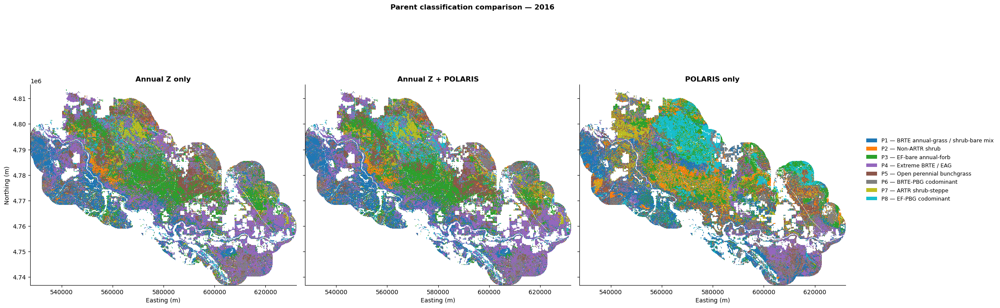

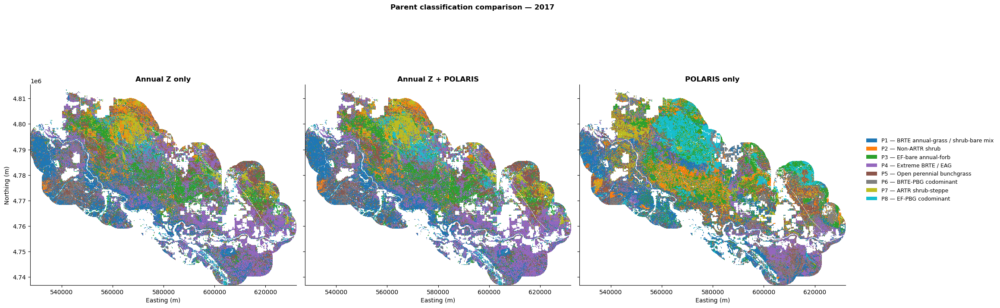

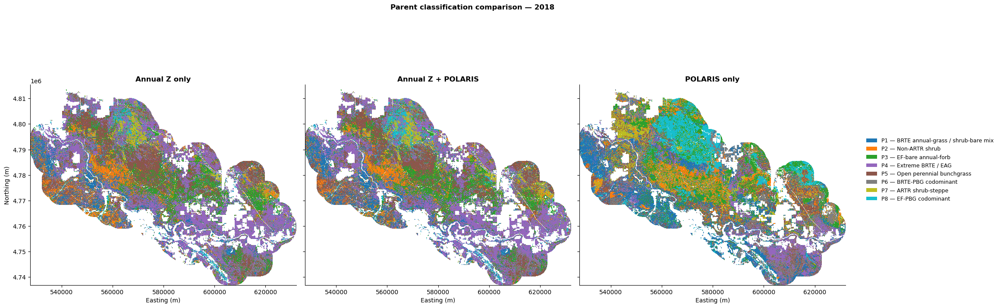

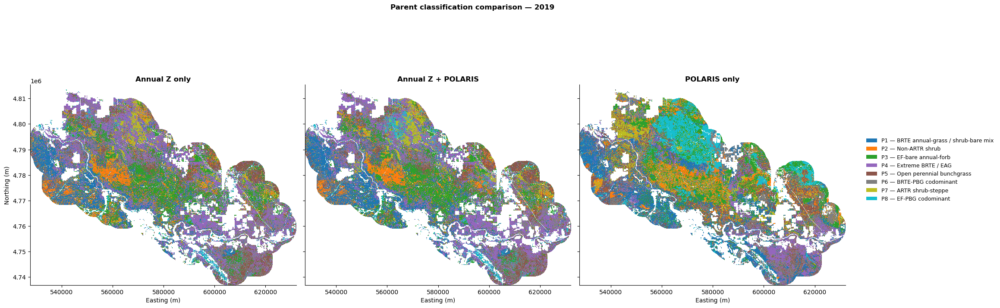

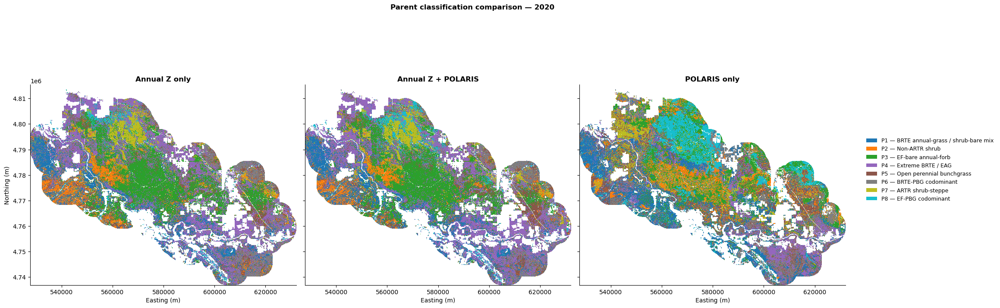

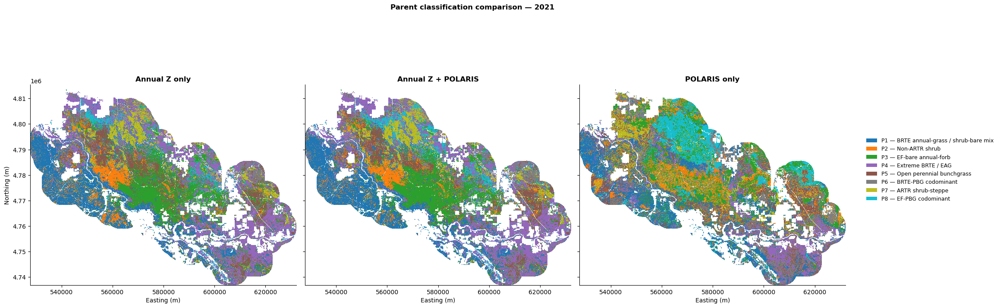

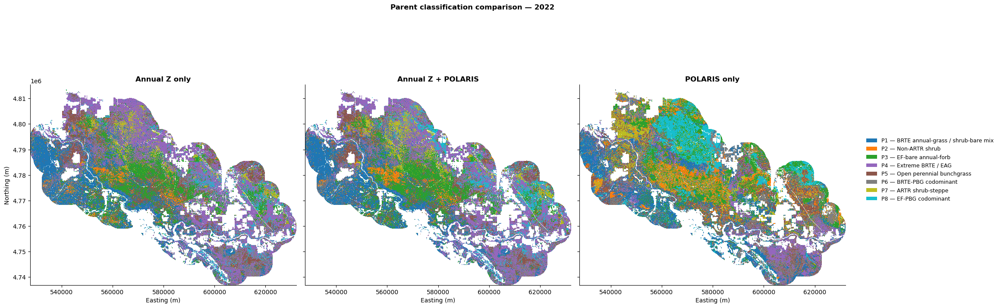

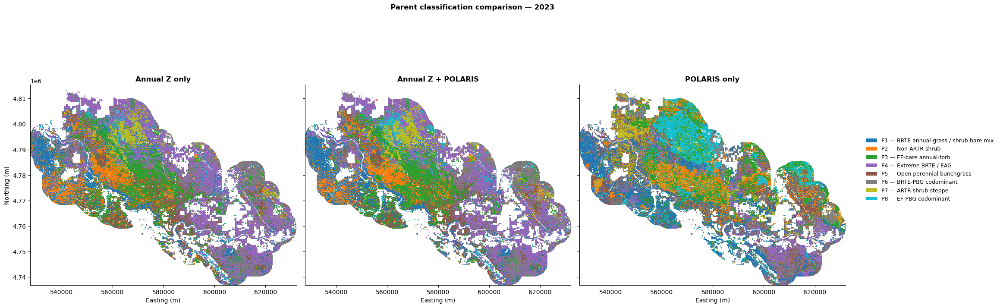

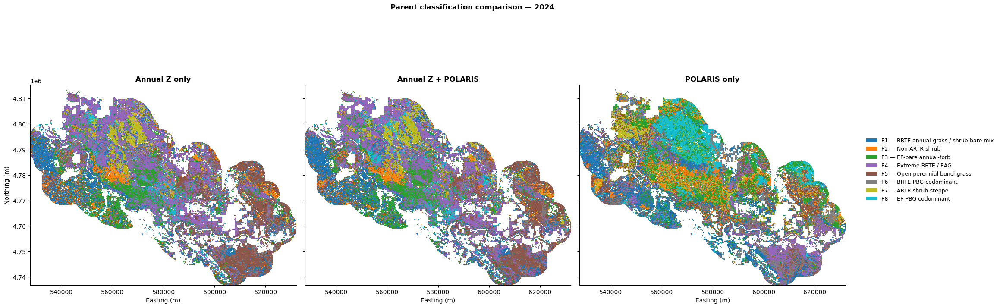

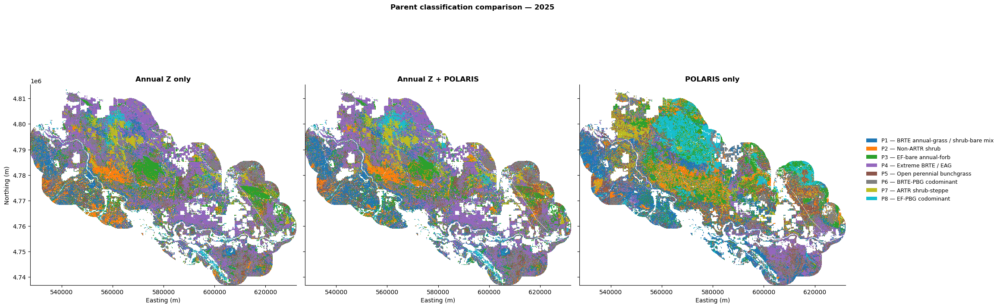

In [33]:
# =============================================================================
# 16. MAP VISUALIZATION
# =============================================================================

PARENT_LABELS = {
    1: "BRTE annual-grass / shrub-bare mix",
    2: "Non-ARTR shrub",
    3: "EF-bare annual-forb",
    4: "Extreme BRTE / EAG",
    5: "Open perennial bunchgrass",
    6: "BRTE-PBG codominant",
    7: "ARTR shrub-steppe",
    8: "EF-PBG codominant",
}


cmap = plt.get_cmap(
    "tab10",
    8,
)

class_norm = BoundaryNorm(
    np.arange(
        0.5,
        9.5,
        1,
    ),
    cmap.N,
)


legend_handles = [
    Patch(
        facecolor=cmap(
            parent - 1
        ),
        edgecolor="none",
        label=(
            f"P{parent} — "
            f"{PARENT_LABELS[parent]}"
        ),
    )
    for parent in VEG_PARENT_CODES
]


if RUN_MAPPING:

    with rasterio.open(
        class_raster_path(
            "polaris"
        )
    ) as src:

        static_polaris = src.read(
            1,
            masked=False,
        )

        bounds = src.bounds


    for year in YEARS_TO_MAP:

        arrays = {}


        for representation in [
            "z",
            "z_plus_polaris",
        ]:

            with rasterio.open(
                class_raster_path(
                    representation,
                    year,
                )
            ) as src:

                arrays[
                    representation
                ] = src.read(
                    1,
                    masked=False,
                )


        arrays[
            "polaris"
        ] = static_polaris


        fig, axes = plt.subplots(
            1,
            3,
            figsize=(
                22,
                8,
            ),
            sharex=True,
            sharey=True,
        )


        panel_titles = {
            "z": "Annual Z only",
            "z_plus_polaris": "Annual Z + POLARIS",
            "polaris": "POLARIS only",
        }


        for ax, representation in zip(
            axes,
            [
                "z",
                "z_plus_polaris",
                "polaris",
            ],
        ):

            arr = np.ma.masked_where(
                ~np.isin(
                    arrays[
                        representation
                    ],
                    VEG_PARENT_CODES,
                ),
                arrays[
                    representation
                ],
            )

            ax.imshow(
                arr,
                cmap=cmap,
                norm=class_norm,
                extent=[
                    bounds.left,
                    bounds.right,
                    bounds.bottom,
                    bounds.top,
                ],
                interpolation="nearest",
            )

            ax.set_title(
                panel_titles[
                    representation
                ],
                fontweight="bold",
            )

            ax.set_xlabel(
                "Easting (m)"
            )

            ax.spines[
                "top"
            ].set_visible(
                False
            )

            ax.spines[
                "right"
            ].set_visible(
                False
            )


        axes[
            0
        ].set_ylabel(
            "Northing (m)"
        )


        fig.suptitle(
            f"Parent classification comparison — {year}",
            fontweight="bold",
        )


        fig.legend(
            handles=legend_handles,
            loc="center left",
            bbox_to_anchor=(
                0.91,
                0.5,
            ),
            frameon=False,
            fontsize=9,
        )


        fig.tight_layout(
            rect=[
                0,
                0,
                0.90,
                0.95,
            ]
        )


        if SAVE_COMPARISON_FIGURES:

            fig.savefig(
                OUTPUT_DIR
                / (
                    f"comparison_Z_POLARIS_"
                    f"{year}.png"
                ),
                dpi=300,
                bbox_inches="tight",
            )


        plt.show()

        plt.close(
            fig
        )


In [34]:
# =============================================================================
# TRUE NCA FOOTPRINT:
#   1. Clip all three mapped representations to the true NCA boundary
#   2. Recompute class frequencies and map agreement using ONLY true-NCA pixels
#   3. Recompute grouped-OOF classification precision using ONLY field plots
#      inside the true NCA
#
# Assumes previous POLARIS notebook cells have already created:
#   - OUTPUT_DIR
#   - YEARS_TO_MAP
#   - MODEL_FOR_MAPPING
#   - VEG_PARENT_CODES
#   - VEG_CLASSES
#   - veg
#   - y
#   - oof_predictions
#   - class_raster_path()
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

from rasterio.mask import mask as rio_mask

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
)


# -----------------------------------------------------------------------------
# INPUT / OUTPUT
# -----------------------------------------------------------------------------

TRUE_NCA_SHP = Path(
    r"C:\NCA_DATA\templates\SRBOP_NCA_extent_26911.shp"
)

TRUE_NCA_OUTPUT_DIR = (
    OUTPUT_DIR
    / "TrueNCA"
)

TRUE_NCA_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# -----------------------------------------------------------------------------
# LOAD TRUE NCA BOUNDARY
# -----------------------------------------------------------------------------

nca = gpd.read_file(
    TRUE_NCA_SHP
)

if nca.crs is None:
    raise ValueError(
        "True NCA shapefile has no CRS."
    )

if nca.empty:
    raise ValueError(
        "True NCA shapefile contains no features."
    )


# Use the mapped classification grid as the canonical CRS.
reference_class_path = class_raster_path(
    "polaris"
)

with rasterio.open(
    reference_class_path
) as ref:
    map_crs = ref.crs

if map_crs is None:
    raise ValueError(
        "Classification raster has no CRS."
    )


# Reproject boundary only if necessary.
if nca.crs != map_crs:
    nca = nca.to_crs(
        map_crs
    )


# Repair/remove empty geometry if needed.
nca = nca.loc[
    nca.geometry.notna()
    & ~nca.geometry.is_empty
].copy()

if nca.empty:
    raise ValueError(
        "No valid NCA geometries remain."
    )


# Geometry list for rasterio.mask.
nca_shapes = [
    geom.__geo_interface__
    for geom in nca.geometry
]


# Unified polygon for field-point filtering.
try:
    nca_union = nca.geometry.union_all()
except AttributeError:
    # Compatibility with older GeoPandas/Shapely
    nca_union = nca.geometry.unary_union


print(
    "True NCA boundary loaded:"
)

print(
    f"  CRS: {nca.crs}"
)

print(
    f"  polygons/features: {len(nca):,}"
)


# =============================================================================
# CLIP FUNCTION
# =============================================================================

def clip_classification_to_nca(
    src_path,
    dst_path,
):

    src_path = Path(
        src_path
    )

    dst_path = Path(
        dst_path
    )

    with rasterio.open(
        src_path
    ) as src:

        if src.crs != map_crs:
            raise ValueError(
                f"Unexpected CRS for {src_path.name}: "
                f"{src.crs} != {map_crs}"
            )

        clipped, clipped_transform = rio_mask(
            src,
            nca_shapes,
            crop=True,
            filled=True,
            nodata=0,
            all_touched=False,
        )

        profile = src.profile.copy()

        profile.update(
            height=clipped.shape[1],
            width=clipped.shape[2],
            transform=clipped_transform,
            nodata=0,
            compress="DEFLATE",
            tiled=True,
            BIGTIFF="IF_SAFER",
        )

        with rasterio.open(
            dst_path,
            "w",
            **profile,
        ) as dst:

            dst.write(
                clipped
            )

    return dst_path


# =============================================================================
# CLIP ALL THREE REPRESENTATIONS
# =============================================================================

clipped_paths = {
    "polaris": {},
    "z": {},
    "z_plus_polaris": {},
}


# -----------------------------------------------------------------------------
# POLARIS ONLY — static, so clip once
# -----------------------------------------------------------------------------

polaris_src = class_raster_path(
    "polaris"
)

polaris_dst = (
    TRUE_NCA_OUTPUT_DIR
    / (
        f"polaris_{MODEL_FOR_MAPPING}_"
        f"static_class_trueNCA.tif"
    )
)

clip_classification_to_nca(
    polaris_src,
    polaris_dst,
)

clipped_paths[
    "polaris"
][
    "static"
] = polaris_dst

print(
    f"Clipped POLARIS -> {polaris_dst.name}"
)


# -----------------------------------------------------------------------------
# ANNUAL Z AND Z + POLARIS
# -----------------------------------------------------------------------------

for year in YEARS_TO_MAP:

    for representation in [
        "z",
        "z_plus_polaris",
    ]:

        src_path = class_raster_path(
            representation,
            year,
        )

        dst_path = (
            TRUE_NCA_OUTPUT_DIR
            / (
                f"{representation}_"
                f"{MODEL_FOR_MAPPING}_"
                f"{year}_class_trueNCA.tif"
            )
        )

        clip_classification_to_nca(
            src_path,
            dst_path,
        )

        clipped_paths[
            representation
        ][
            year
        ] = dst_path

    print(
        f"True-NCA clipping complete: {year}"
    )


# =============================================================================
# PIXEL-LEVEL EVALUATION INSIDE TRUE NCA
#
# This evaluates:
#   - class composition
#   - exact agreement among the three representations
#
# It does NOT call agreement "accuracy" because there is no wall-to-wall
# ground truth raster.
# =============================================================================

frequency_records_nca = []
agreement_records_nca = []


with rasterio.open(
    polaris_dst
) as src:

    polaris_map_nca = src.read(
        1,
        masked=False,
    )

    nca_transform = src.transform
    nca_shape = (
        src.height,
        src.width,
    )


for year in YEARS_TO_MAP:

    maps = {
        "polaris": polaris_map_nca,
    }


    for representation in [
        "z",
        "z_plus_polaris",
    ]:

        with rasterio.open(
            clipped_paths[
                representation
            ][
                year
            ]
        ) as src:

            if (
                src.height,
                src.width,
            ) != nca_shape:

                raise ValueError(
                    f"Grid shape mismatch for "
                    f"{representation} {year}."
                )

            if src.transform != nca_transform:

                raise ValueError(
                    f"Grid transform mismatch for "
                    f"{representation} {year}."
                )

            maps[
                representation
            ] = src.read(
                1,
                masked=False,
            )


    # -------------------------------------------------------------------------
    # Class frequencies
    # -------------------------------------------------------------------------

    for representation, arr in maps.items():

        valid = np.isin(
            arr,
            VEG_PARENT_CODES,
        )

        total = int(
            valid.sum()
        )

        if total == 0:
            raise ValueError(
                f"No valid classified NCA pixels for "
                f"{representation}, {year}."
            )

        codes, counts = np.unique(
            arr[
                valid
            ],
            return_counts=True,
        )

        for code_value, count in zip(
            codes,
            counts,
        ):

            frequency_records_nca.append(
                {
                    "Year": year,
                    "representation": representation,
                    "class_code": int(
                        code_value
                    ),
                    "n_pixels": int(
                        count
                    ),
                    "percent": (
                        100.0
                        * count
                        / total
                    ),
                    "total_valid_NCA_pixels": total,
                }
            )


    # -------------------------------------------------------------------------
    # Pairwise map agreement
    # -------------------------------------------------------------------------

    pairs = [
        (
            "z",
            "z_plus_polaris",
        ),
        (
            "z",
            "polaris",
        ),
        (
            "z_plus_polaris",
            "polaris",
        ),
    ]


    for a_name, b_name in pairs:

        a = maps[
            a_name
        ]

        b = maps[
            b_name
        ]

        valid_pair = (
            np.isin(
                a,
                VEG_PARENT_CODES,
            )
            & np.isin(
                b,
                VEG_PARENT_CODES,
            )
        )

        n_pair = int(
            valid_pair.sum()
        )

        if n_pair == 0:

            exact_agreement = np.nan

        else:

            exact_agreement = float(
                np.mean(
                    a[
                        valid_pair
                    ]
                    ==
                    b[
                        valid_pair
                    ]
                )
            )


        agreement_records_nca.append(
            {
                "Year": year,
                "map_a": a_name,
                "map_b": b_name,
                "n_paired_pixels": n_pair,
                "exact_agreement": exact_agreement,
            }
        )


true_nca_frequency_df = pd.DataFrame(
    frequency_records_nca
)

true_nca_agreement_df = pd.DataFrame(
    agreement_records_nca
)


true_nca_frequency_df.to_csv(
    TRUE_NCA_OUTPUT_DIR
    / "trueNCA_class_frequencies.csv",
    index=False,
)

true_nca_agreement_df.to_csv(
    TRUE_NCA_OUTPUT_DIR
    / "trueNCA_map_agreement.csv",
    index=False,
)


print(
    "\nPairwise map agreement — TRUE NCA only"
)

display(
    true_nca_agreement_df.round(
        4
    )
)


# =============================================================================
# GROUPED-OOF CLASSIFICATION PRECISION WITHIN TRUE NCA
#
# IMPORTANT:
# These are the existing PlotID-grouped OOF predictions restricted spatially
# to field observations inside the true NCA.
#
# Therefore:
#   - NOT resubstitution accuracy
#   - NOT wall-to-wall pixel validation
#   - still NOT a spatial-block independence test
# =============================================================================

veg_points = gpd.GeoDataFrame(
    veg.copy(),
    geometry=gpd.points_from_xy(
        veg[
            "Easting"
        ].astype(float),
        veg[
            "Northing"
        ].astype(float),
    ),
    crs=map_crs,
)


# covers() includes points exactly on the NCA boundary.
inside_true_nca = np.array(
    [
        nca_union.covers(
            geom
        )
        for geom in veg_points.geometry
    ],
    dtype=bool,
)


print(
    "\nField observations:"
)

print(
    f"  common ML rows: {len(veg_points):,}"
)

print(
    f"  inside true NCA: {inside_true_nca.sum():,}"
)

print(
    f"  outside true NCA / buffer-only: "
    f"{(~inside_true_nca).sum():,}"
)


if inside_true_nca.sum() == 0:
    raise ValueError(
        "No vegetation observations fall inside the true NCA."
    )


y_true_nca = y[
    inside_true_nca
]


# -----------------------------------------------------------------------------
# Pooled grouped-OOF metrics inside true NCA
# -----------------------------------------------------------------------------

precision_summary_records = []
precision_class_records = []


for representation in [
    "z",
    "polaris",
    "z_plus_polaris",
]:

    y_pred_all = np.asarray(
        oof_predictions[
            representation
        ][
            MODEL_FOR_MAPPING
        ]
    ).astype(str)

    y_pred_nca = y_pred_all[
        inside_true_nca
    ]


    precision_summary_records.append(
        {
            "representation": representation,
            "model": MODEL_FOR_MAPPING,
            "n_reference_observations": len(
                y_true_nca
            ),
            "accuracy": accuracy_score(
                y_true_nca,
                y_pred_nca,
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_true_nca,
                y_pred_nca,
            ),
            "macro_precision": precision_score(
                y_true_nca,
                y_pred_nca,
                labels=VEG_CLASSES,
                average="macro",
                zero_division=0,
            ),
            "weighted_precision": precision_score(
                y_true_nca,
                y_pred_nca,
                labels=VEG_CLASSES,
                average="weighted",
                zero_division=0,
            ),
            "macro_f1": f1_score(
                y_true_nca,
                y_pred_nca,
                labels=VEG_CLASSES,
                average="macro",
                zero_division=0,
            ),
        }
    )


    report = classification_report(
        y_true_nca,
        y_pred_nca,
        labels=VEG_CLASSES,
        output_dict=True,
        zero_division=0,
    )


    for parent_code in VEG_PARENT_CODES:

        class_name = f"VEG::{parent_code}"

        metrics = report[
            class_name
        ]

        precision_class_records.append(
            {
                "representation": representation,
                "model": MODEL_FOR_MAPPING,
                "parent_class": f"P{parent_code}",
                "precision": metrics[
                    "precision"
                ],
                "recall": metrics[
                    "recall"
                ],
                "f1": metrics[
                    "f1-score"
                ],
                "support": int(
                    metrics[
                        "support"
                    ]
                ),
            }
        )


true_nca_precision_summary = pd.DataFrame(
    precision_summary_records
)

true_nca_precision_by_class = pd.DataFrame(
    precision_class_records
)


true_nca_precision_summary.to_csv(
    TRUE_NCA_OUTPUT_DIR
    / "trueNCA_groupedOOF_precision_summary.csv",
    index=False,
)

true_nca_precision_by_class.to_csv(
    TRUE_NCA_OUTPUT_DIR
    / "trueNCA_groupedOOF_precision_by_class.csv",
    index=False,
)


print(
    "\nGrouped-OOF performance — TRUE NCA field observations only"
)

display(
    true_nca_precision_summary.round(
        4
    )
)


print(
    "\nClass-specific precision / recall — TRUE NCA only"
)

display(
    true_nca_precision_by_class.round(
        4
    )
)


# =============================================================================
# YEAR-SPECIFIC OOF PERFORMANCE FOR OBSERVED VEGETATION YEARS
# =============================================================================

yearly_precision_records = []


veg_years_array = veg[
    "Year"
].to_numpy(
    dtype=int
)


for year in sorted(
    np.unique(
        veg_years_array[
            inside_true_nca
        ]
    )
):

    year_mask = (
        inside_true_nca
        & (
            veg_years_array
            == year
        )
    )

    y_true_year = y[
        year_mask
    ]


    for representation in [
        "z",
        "polaris",
        "z_plus_polaris",
    ]:

        y_pred_year = np.asarray(
            oof_predictions[
                representation
            ][
                MODEL_FOR_MAPPING
            ]
        ).astype(str)[
            year_mask
        ]


        yearly_precision_records.append(
            {
                "Year": int(
                    year
                ),
                "representation": representation,
                "model": MODEL_FOR_MAPPING,
                "n_reference_observations": int(
                    year_mask.sum()
                ),
                "accuracy": accuracy_score(
                    y_true_year,
                    y_pred_year,
                ),
                "balanced_accuracy": balanced_accuracy_score(
                    y_true_year,
                    y_pred_year,
                ),
                "macro_precision": precision_score(
                    y_true_year,
                    y_pred_year,
                    labels=VEG_CLASSES,
                    average="macro",
                    zero_division=0,
                ),
                "macro_f1": f1_score(
                    y_true_year,
                    y_pred_year,
                    labels=VEG_CLASSES,
                    average="macro",
                    zero_division=0,
                ),
            }
        )


true_nca_yearly_precision = pd.DataFrame(
    yearly_precision_records
)

true_nca_yearly_precision.to_csv(
    TRUE_NCA_OUTPUT_DIR
    / "trueNCA_groupedOOF_precision_by_year.csv",
    index=False,
)


print(
    "\nGrouped-OOF performance by vegetation year — TRUE NCA only"
)

display(
    true_nca_yearly_precision.round(
        4
    )
)


print(
    "\nTRUE NCA evaluation complete."
)

print(
    f"Outputs: {TRUE_NCA_OUTPUT_DIR}"
)

True NCA boundary loaded:
  CRS: EPSG:26911
  polygons/features: 1
Clipped POLARIS -> polaris_random_forest_static_class_trueNCA.tif
True-NCA clipping complete: 2016
True-NCA clipping complete: 2017
True-NCA clipping complete: 2018
True-NCA clipping complete: 2019
True-NCA clipping complete: 2020
True-NCA clipping complete: 2021
True-NCA clipping complete: 2022
True-NCA clipping complete: 2023
True-NCA clipping complete: 2024
True-NCA clipping complete: 2025

Pairwise map agreement — TRUE NCA only


,Year,map_a,map_b,n_paired_pixels,exact_agreement
0,2016,z,z_plus_polaris,22009780,0.8355
1,2016,z,polaris,22009780,0.1989
2,2016,z_plus_polaris,polaris,22009780,0.2523
3,2017,z,z_plus_polaris,22049257,0.8125
4,2017,z,polaris,22049257,0.1854
5,2017,z_plus_polaris,polaris,22049257,0.2373
6,2018,z,z_plus_polaris,22048888,0.8426
7,2018,z,polaris,22048888,0.1747
8,2018,z_plus_polaris,polaris,22048888,0.2223
9,2019,z,z_plus_polaris,22057243,0.8137



Field observations:
  common ML rows: 479
  inside true NCA: 354
  outside true NCA / buffer-only: 125

Grouped-OOF performance — TRUE NCA field observations only


,representation,model,n_reference_observations,accuracy,balanced_accuracy,macro_precision,weighted_precision,macro_f1
0,z,random_forest,354,0.4576,0.4175,0.4876,0.4699,0.4307
1,polaris,random_forest,354,0.2316,0.2196,0.2301,0.2422,0.2226
2,z_plus_polaris,random_forest,354,0.5028,0.4504,0.5205,0.5090,0.4615



Class-specific precision / recall — TRUE NCA only


,representation,model,parent_class,precision,recall,f1,support
0,z,random_forest,P1,0.4677,0.5273,0.4957,55
1,z,random_forest,P2,0.4043,0.4222,0.4130,45
2,z,random_forest,P3,0.4348,0.5172,0.4724,58
3,z,random_forest,P4,0.5286,0.5781,0.5522,64
4,z,random_forest,P5,0.4286,0.4528,0.4404,53
5,z,random_forest,P6,0.3548,0.3235,0.3385,34
6,z,random_forest,P7,0.6154,0.2963,0.4000,27
7,z,random_forest,P8,0.6667,0.2222,0.3333,18
8,polaris,random_forest,P1,0.2121,0.2545,0.2314,55
9,polaris,random_forest,P2,0.2326,0.2222,0.2273,45



Grouped-OOF performance by vegetation year — TRUE NCA only


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,Year,representation,model,n_reference_observations,accuracy,balanced_accuracy,macro_precision,macro_f1
0,2016,z,random_forest,190,0.4368,0.3727,0.4058,0.3719
1,2016,polaris,random_forest,190,0.1737,0.1448,0.1376,0.1377
2,2016,z_plus_polaris,random_forest,190,0.4684,0.3938,0.4105,0.3851
3,2018,z,random_forest,66,0.4545,0.3875,0.3318,0.3298
4,2018,polaris,random_forest,66,0.2576,0.2037,0.2064,0.1842
5,2018,z_plus_polaris,random_forest,66,0.5000,0.4357,0.3606,0.3625
6,2025,z,random_forest,98,0.5000,0.4135,0.4869,0.4335
7,2025,polaris,random_forest,98,0.3265,0.2945,0.3017,0.2905
8,2025,z_plus_polaris,random_forest,98,0.5714,0.4799,0.5061,0.4862



TRUE NCA evaluation complete.
Outputs: C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POLARIS\TrueNCA


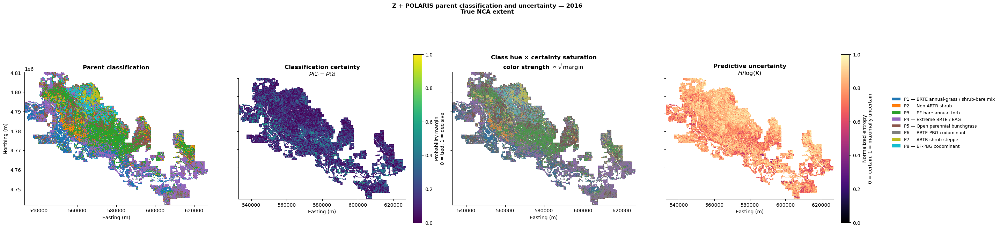

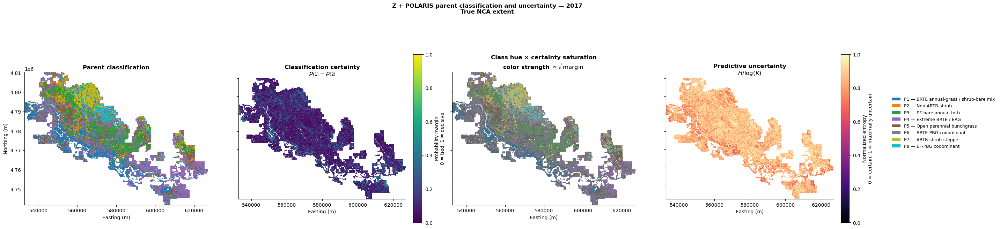

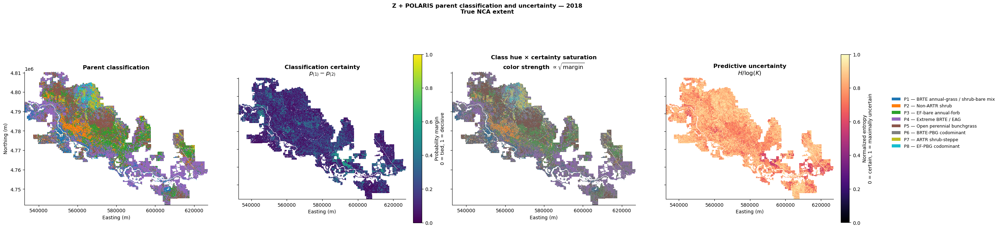

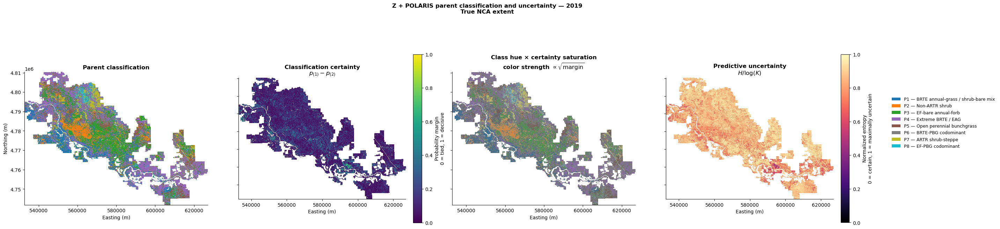

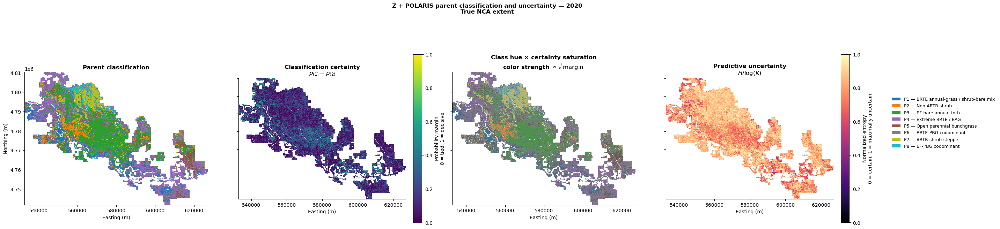

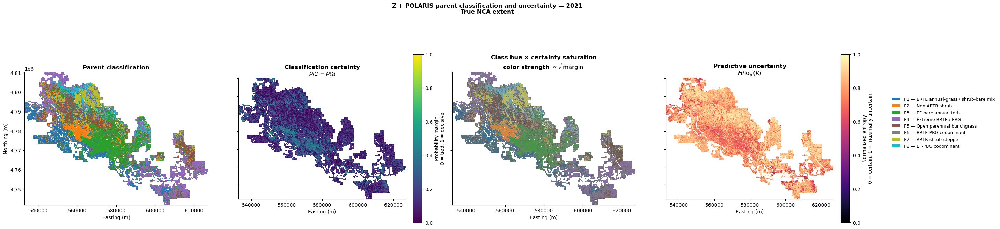

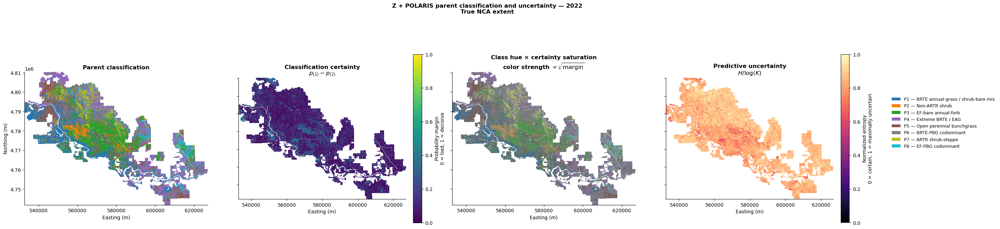

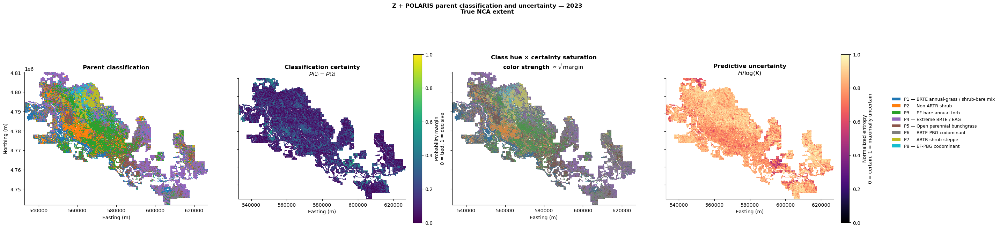

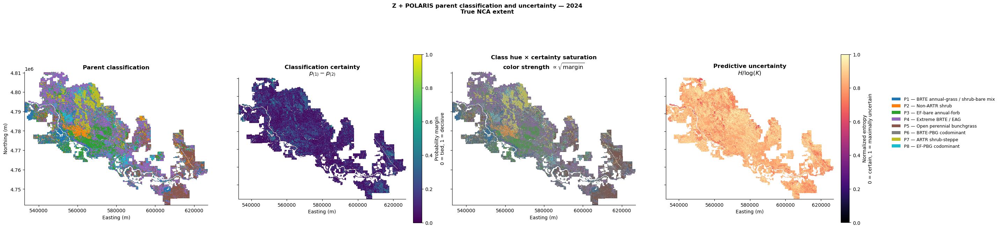

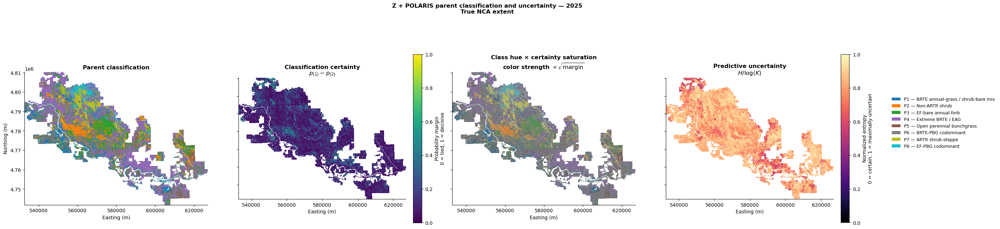


Z + POLARIS uncertainty summary — TRUE NCA


,Year,n_valid_pixels,mean_max_probability,median_max_probability,mean_probability_margin,margin_p10,margin_p25,margin_p50,margin_p75,margin_p90,mean_normalized_entropy,median_normalized_entropy
0,2016,22009780,0.3717,0.3539,0.1601,0.0190,0.0520,0.1248,0.2389,0.3550,0.8127,0.8301
1,2017,22049257,0.3289,0.3104,0.1228,0.0141,0.0384,0.0915,0.1793,0.2811,0.8523,0.8667
2,2018,22048888,0.3715,0.3536,0.1643,0.0193,0.0531,0.1283,0.2454,0.3659,0.8151,0.8310
3,2019,22057243,0.3385,0.3215,0.1281,0.0149,0.0405,0.0968,0.1865,0.2869,0.8399,0.8568
4,2020,22065310,0.3712,0.3506,0.1624,0.0187,0.0517,0.1266,0.2404,0.3623,0.8142,0.8365
5,2021,22062913,0.3752,0.3592,0.1633,0.0205,0.0563,0.1331,0.2437,0.3551,0.8066,0.8234
6,2022,22058530,0.3321,0.3159,0.1201,0.0139,0.0377,0.0894,0.1741,0.2742,0.8431,0.8534
7,2023,22068032,0.3579,0.3394,0.1436,0.0167,0.0453,0.1082,0.2096,0.3228,0.8203,0.8364
8,2024,22069019,0.3322,0.3177,0.1234,0.0148,0.0398,0.0935,0.1803,0.2781,0.8488,0.8550
9,2025,22062129,0.3485,0.3293,0.1267,0.0141,0.0383,0.0919,0.1816,0.2906,0.8219,0.8449



Primary certainty diagnostics:


,Year,mean_probability_margin,margin_p10,margin_p25,margin_p50,margin_p75,margin_p90,mean_max_probability,mean_normalized_entropy
0,2016,0.1601,0.0190,0.0520,0.1248,0.2389,0.3550,0.3717,0.8127
1,2017,0.1228,0.0141,0.0384,0.0915,0.1793,0.2811,0.3289,0.8523
2,2018,0.1643,0.0193,0.0531,0.1283,0.2454,0.3659,0.3715,0.8151
3,2019,0.1281,0.0149,0.0405,0.0968,0.1865,0.2869,0.3385,0.8399
4,2020,0.1624,0.0187,0.0517,0.1266,0.2404,0.3623,0.3712,0.8142
5,2021,0.1633,0.0205,0.0563,0.1331,0.2437,0.3551,0.3752,0.8066
6,2022,0.1201,0.0139,0.0377,0.0894,0.1741,0.2742,0.3321,0.8431
7,2023,0.1436,0.0167,0.0453,0.1082,0.2096,0.3228,0.3579,0.8203
8,2024,0.1234,0.0148,0.0398,0.0935,0.1803,0.2781,0.3322,0.8488
9,2025,0.1267,0.0141,0.0383,0.0919,0.1816,0.2906,0.3485,0.8219


In [38]:
# =============================================================================
# Z + POLARIS — TRUE NCA CLASSIFICATION + UNCERTAINTY VISUALIZATION
#
# Panels:
#   1. Parent classification
#   2. Probability margin:
#          p(best class) - p(second-best class)
#      Higher = more certain
#   3. Parent class hue × probability-margin saturation
#      Hue = predicted parent
#      Saturation = classification certainty
#   4. Normalized predictive entropy
#          H / log(K)
#      Higher = more uncertain
#
# IMPORTANT:
#   - No per-year min/max scaling of the uncertainty statistics.
#   - Margin remains on its theoretical 0–1 scale.
#   - Entropy is normalized by log(K), so it is also on 0–1.
#   - The nonlinear transform used for panel 3 affects DISPLAY ONLY.
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch


# =============================================================================
# 1. SETTINGS
# =============================================================================

TRUE_NCA_SHP = Path(
    r"C:\NCA_DATA\templates\SRBOP_NCA_extent_26911.shp"
)

REPRESENTATION = "z_plus_polaris"

SAVE_UNCERTAINTY_FIGURES = True

UNCERTAINTY_FIG_DIR = (
    OUTPUT_DIR
    / "TrueNCA_Uncertainty_Figures"
)

UNCERTAINTY_FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# -----------------------------------------------------------------------------
# DISPLAY ONLY
#
# Probability margins are often numerically modest in an 8-class problem.
# Using margin directly as saturation can therefore make nearly everything gray.
#
# gamma < 1 expands the visual contrast among low/moderate margins WITHOUT
# altering any quantitative uncertainty values.
#
# display_strength = margin ** SATURATION_GAMMA
# -----------------------------------------------------------------------------

SATURATION_GAMMA = 0.50

# Minimum amount of class color retained even at margin = 0.
MIN_COLOR_STRENGTH = 0.08


# =============================================================================
# 2. CLASS LABELS / CATEGORICAL PALETTE
# =============================================================================

PARENT_LABELS = {
    1: "BRTE annual-grass / shrub-bare mix",
    2: "Non-ARTR shrub",
    3: "EF-bare annual-forb",
    4: "Extreme BRTE / EAG",
    5: "Open perennial bunchgrass",
    6: "BRTE-PBG codominant",
    7: "ARTR shrub-steppe",
    8: "EF-PBG codominant",
}


cmap = plt.get_cmap(
    "tab10",
    8,
)


class_norm = BoundaryNorm(
    np.arange(
        0.5,
        9.5,
        1.0,
    ),
    cmap.N,
)


legend_handles = [
    Patch(
        facecolor=cmap(
            parent - 1
        ),
        edgecolor="none",
        label=(
            f"P{parent} — "
            f"{PARENT_LABELS[parent]}"
        ),
    )
    for parent in VEG_PARENT_CODES
]


# =============================================================================
# 3. PATH HELPERS
# =============================================================================

def class_path(
    year,
):
    return (
        OUTPUT_DIR
        / (
            f"{REPRESENTATION}_"
            f"{MODEL_FOR_MAPPING}_"
            f"{year}_class.tif"
        )
    )


def uncertainty_path(
    year,
):
    return (
        OUTPUT_DIR
        / (
            f"{REPRESENTATION}_"
            f"{MODEL_FOR_MAPPING}_"
            f"{year}_uncertainty.tif"
        )
    )


# =============================================================================
# 4. TRUE NCA GEOMETRY
# =============================================================================

nca = gpd.read_file(
    TRUE_NCA_SHP
)


if nca.crs is None:
    raise ValueError(
        "True NCA shapefile has no CRS."
    )


if nca.empty:
    raise ValueError(
        "True NCA shapefile is empty."
    )


# Use first classification raster as canonical raster CRS.
with rasterio.open(
    class_path(
        YEARS_TO_MAP[0]
    )
) as ref:

    raster_crs = ref.crs


if raster_crs is None:
    raise ValueError(
        "Classification raster has no CRS."
    )


if nca.crs != raster_crs:

    nca = nca.to_crs(
        raster_crs
    )


nca = nca.loc[
    nca.geometry.notna()
    & ~nca.geometry.is_empty
].copy()


if nca.empty:
    raise ValueError(
        "No valid NCA geometries remain."
    )


nca_shapes = [
    geom.__geo_interface__
    for geom in nca.geometry
]


# =============================================================================
# 5. READ + CLIP ONE YEAR
# =============================================================================

def read_true_nca_year(
    year,
):

    cls_path = class_path(
        year
    )

    unc_path = uncertainty_path(
        year
    )


    # -------------------------------------------------------------------------
    # CLASSIFICATION
    # -------------------------------------------------------------------------

    with rasterio.open(
        cls_path
    ) as src:

        cls_clip, cls_transform = rio_mask(
            src,
            nca_shapes,
            crop=True,
            filled=True,
            nodata=0,
            all_touched=False,
        )


    class_arr = cls_clip[
        0
    ]


    # -------------------------------------------------------------------------
    # UNCERTAINTY
    # -------------------------------------------------------------------------

    with rasterio.open(
        unc_path
    ) as src:

        descriptions = list(
            src.descriptions
        )

        unc_nodata = (
            src.nodata
            if src.nodata is not None
            else -9999.0
        )

        unc_clip, unc_transform = rio_mask(
            src,
            nca_shapes,
            crop=True,
            filled=True,
            nodata=unc_nodata,
            all_touched=False,
        )


    if cls_transform != unc_transform:

        raise ValueError(
            f"Class/uncertainty transform mismatch for {year}."
        )


    if (
        class_arr.shape
        != unc_clip.shape[1:]
    ):

        raise ValueError(
            f"Class/uncertainty shape mismatch for {year}."
        )


    uncertainty = unc_clip.astype(
        np.float64
    )


    # Convert nodata to NaN.
    uncertainty[
        uncertainty
        == unc_nodata
    ] = np.nan


    # -------------------------------------------------------------------------
    # IDENTIFY BANDS BY DESCRIPTION
    # -------------------------------------------------------------------------

    band_lookup = {
        str(
            description
        ).strip().lower(): i
        for i, description in enumerate(
            descriptions
        )
        if description is not None
    }


    required = [
        "max_probability",
        "probability_margin",
        "prediction_entropy",
    ]


    missing = [
        band
        for band in required
        if band not in band_lookup
    ]


    if missing:

        raise KeyError(
            f"{year} uncertainty TIFF is missing bands: {missing}. "
            f"Found descriptions: {descriptions}"
        )


    pmax = uncertainty[
        band_lookup[
            "max_probability"
        ]
    ]


    margin = uncertainty[
        band_lookup[
            "probability_margin"
        ]
    ]


    entropy = uncertainty[
        band_lookup[
            "prediction_entropy"
        ]
    ]


    # Theoretical ranges.
    pmax = np.clip(
        pmax,
        0.0,
        1.0,
    )


    margin = np.clip(
        margin,
        0.0,
        1.0,
    )


    # Normalize entropy by maximum possible entropy:
    #
    #     H_max = log(K)
    #
    # so:
    #
    #     entropy_relative = 0 -> concentrated probability
    #     entropy_relative = 1 -> uniform probability over classes
    #
    max_entropy = np.log(
        len(
            VEG_PARENT_CODES
        )
    )


    entropy_relative = np.clip(
        entropy
        / max_entropy,
        0.0,
        1.0,
    )


    valid_class = np.isin(
        class_arr,
        VEG_PARENT_CODES,
    )


    # Enforce common valid support.
    valid = (
        valid_class
        & np.isfinite(
            pmax
        )
        & np.isfinite(
            margin
        )
        & np.isfinite(
            entropy_relative
        )
    )


    pmax = np.where(
        valid,
        pmax,
        np.nan,
    )


    margin = np.where(
        valid,
        margin,
        np.nan,
    )


    entropy_relative = np.where(
        valid,
        entropy_relative,
        np.nan,
    )


    return {
        "class": class_arr,
        "valid": valid,
        "pmax": pmax,
        "margin": margin,
        "entropy_relative": entropy_relative,
        "transform": cls_transform,
        "class_path": cls_path,
        "uncertainty_path": unc_path,
    }


# =============================================================================
# 6. CATEGORICAL HUE × CERTAINTY SATURATION
# =============================================================================

def certainty_saturated_rgb(
    class_arr,
    margin,
    valid,
):
    """
    Hue is determined by predicted parent class.

    Probability margin controls the amount of categorical color.

    Low margin:
        class color is strongly desaturated toward a luminance-matched gray.

    High margin:
        full categorical color.

    SATURATION_GAMMA affects visualization only.
    Quantitative margin values are untouched.
    """

    rows, cols = class_arr.shape


    # White outside valid analysis support.
    rgb = np.ones(
        (
            rows,
            cols,
            3,
        ),
        dtype=np.float32,
    )


    # Nonlinear DISPLAY mapping only.
    certainty_display = np.power(
        np.clip(
            margin,
            0.0,
            1.0,
        ),
        SATURATION_GAMMA,
    )


    strength = (
        MIN_COLOR_STRENGTH
        + (
            1.0
            - MIN_COLOR_STRENGTH
        )
        * certainty_display
    )


    for parent in VEG_PARENT_CODES:

        parent_mask = (
            valid
            & (
                class_arr
                == parent
            )
        )


        if not np.any(
            parent_mask
        ):
            continue


        class_rgb = np.asarray(
            cmap(
                parent - 1
            )[
                :3
            ],
            dtype=np.float32,
        )


        # Luminance-matched neutral version of that color.
        #
        # This changes saturation much more than brightness,
        # avoiding the washed-out alpha effect.
        luminance = float(
            0.2126
            * class_rgb[0]
            + 0.7152
            * class_rgb[1]
            + 0.0722
            * class_rgb[2]
        )


        neutral_rgb = np.array(
            [
                luminance,
                luminance,
                luminance,
            ],
            dtype=np.float32,
        )


        w = strength[
            parent_mask
        ][
            :,
            None
        ]


        rgb[
            parent_mask
        ] = (
            neutral_rgb[
                None,
                :
            ]
            * (
                1.0
                - w
            )
            + class_rgb[
                None,
                :
            ]
            * w
        )


    return rgb


# =============================================================================
# 7. RUN ALL YEARS
# =============================================================================

uncertainty_summary_records = []


for year in YEARS_TO_MAP:

    data = read_true_nca_year(
        year
    )


    class_arr = data[
        "class"
    ]

    valid = data[
        "valid"
    ]

    pmax = data[
        "pmax"
    ]

    margin = data[
        "margin"
    ]

    entropy_relative = data[
        "entropy_relative"
    ]

    transform = data[
        "transform"
    ]


    # -------------------------------------------------------------------------
    # SUMMARY STATISTICS
    # -------------------------------------------------------------------------

    margin_valid = margin[
        valid
    ]

    pmax_valid = pmax[
        valid
    ]

    entropy_valid = entropy_relative[
        valid
    ]


    margin_quantiles = np.quantile(
        margin_valid,
        [
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ],
    )


    uncertainty_summary_records.append(
        {
            "Year": year,
            "n_valid_pixels": int(
                valid.sum()
            ),

            "mean_max_probability": float(
                np.mean(
                    pmax_valid
                )
            ),

            "median_max_probability": float(
                np.median(
                    pmax_valid
                )
            ),

            "mean_probability_margin": float(
                np.mean(
                    margin_valid
                )
            ),

            "margin_p10": float(
                margin_quantiles[0]
            ),

            "margin_p25": float(
                margin_quantiles[1]
            ),

            "margin_p50": float(
                margin_quantiles[2]
            ),

            "margin_p75": float(
                margin_quantiles[3]
            ),

            "margin_p90": float(
                margin_quantiles[4]
            ),

            "mean_normalized_entropy": float(
                np.mean(
                    entropy_valid
                )
            ),

            "median_normalized_entropy": float(
                np.median(
                    entropy_valid
                )
            ),
        }
    )


    # -------------------------------------------------------------------------
    # DISPLAY EXTENT
    # -------------------------------------------------------------------------

    left = transform.c

    top = transform.f

    right = (
        left
        + transform.a
        * class_arr.shape[1]
    )

    bottom = (
        top
        + transform.e
        * class_arr.shape[0]
    )


    extent = [
        left,
        right,
        bottom,
        top,
    ]


    # -------------------------------------------------------------------------
    # DISPLAY ARRAYS
    # -------------------------------------------------------------------------

    class_masked = np.ma.masked_where(
        ~valid,
        class_arr,
    )


    margin_masked = np.ma.masked_invalid(
        margin
    )


    entropy_masked = np.ma.masked_invalid(
        entropy_relative
    )


    certainty_rgb = certainty_saturated_rgb(
        class_arr=class_arr,
        margin=margin,
        valid=valid,
    )


    # -------------------------------------------------------------------------
    # FIGURE
    # -------------------------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(
            28,
            7,
        ),
        sharex=True,
        sharey=True,
    )


    # -------------------------------------------------------------------------
    # PANEL 1 — CLASSIFICATION
    # -------------------------------------------------------------------------

    axes[0].imshow(
        class_masked,
        cmap=cmap,
        norm=class_norm,
        extent=extent,
        interpolation="nearest",
    )


    axes[0].set_title(
        "Parent classification",
        fontweight="bold",
    )


    # -------------------------------------------------------------------------
    # PANEL 2 — PROBABILITY MARGIN
    # -------------------------------------------------------------------------

    im_margin = axes[1].imshow(
        margin_masked,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        extent=extent,
        interpolation="nearest",
    )


    axes[1].set_title(
        "Classification certainty\n"
        r"$p_{(1)} - p_{(2)}$",
        fontweight="bold",
    )


    cbar_margin = fig.colorbar(
        im_margin,
        ax=axes[1],
        fraction=0.046,
        pad=0.04,
    )


    cbar_margin.set_label(
        "Probability margin\n"
        "0 = tied, 1 = decisive"
    )


    # -------------------------------------------------------------------------
    # PANEL 3 — HUE × SATURATION
    # -------------------------------------------------------------------------

    axes[2].imshow(
        certainty_rgb,
        extent=extent,
        interpolation="nearest",
    )


    axes[2].set_title(
        "Class hue × certainty saturation\n"
        r"color strength $\propto \sqrt{\mathrm{margin}}$",
        fontweight="bold",
    )


    # -------------------------------------------------------------------------
    # PANEL 4 — NORMALIZED ENTROPY
    # -------------------------------------------------------------------------

    im_entropy = axes[3].imshow(
        entropy_masked,
        cmap="magma",
        vmin=0.0,
        vmax=1.0,
        extent=extent,
        interpolation="nearest",
    )


    axes[3].set_title(
        "Predictive uncertainty\n"
        r"$H / \log(K)$",
        fontweight="bold",
    )


    cbar_entropy = fig.colorbar(
        im_entropy,
        ax=axes[3],
        fraction=0.046,
        pad=0.04,
    )


    cbar_entropy.set_label(
        "Normalized entropy\n"
        "0 = certain, 1 = maximally uncertain"
    )


    # -------------------------------------------------------------------------
    # AXIS FORMATTING
    # -------------------------------------------------------------------------

    for ax in axes:

        ax.set_xlabel(
            "Easting (m)"
        )

        ax.spines[
            "top"
        ].set_visible(
            False
        )

        ax.spines[
            "right"
        ].set_visible(
            False
        )


    axes[
        0
    ].set_ylabel(
        "Northing (m)"
    )


    # -------------------------------------------------------------------------
    # TITLE + LEGEND
    # -------------------------------------------------------------------------

    fig.suptitle(
        (
            f"Z + POLARIS parent classification and uncertainty — {year}\n"
            "True NCA extent"
        ),
        fontweight="bold",
        y=0.99,
    )


    fig.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(
            0.91,
            0.50,
        ),
        frameon=False,
        fontsize=9,
    )


    fig.tight_layout(
        rect=[
            0.00,
            0.00,
            0.90,
            0.94,
        ]
    )


    # -------------------------------------------------------------------------
    # SAVE
    # -------------------------------------------------------------------------

    if SAVE_UNCERTAINTY_FIGURES:

        fig.savefig(
            UNCERTAINTY_FIG_DIR
            / (
                f"z_plus_polaris_"
                f"{year}_"
                f"trueNCA_class_uncertainty.png"
            ),
            dpi=300,
            bbox_inches="tight",
        )


    plt.show()

    plt.close(
        fig
    )


# =============================================================================
# 8. UNCERTAINTY SUMMARY ACROSS YEARS
# =============================================================================

uncertainty_summary_df = pd.DataFrame(
    uncertainty_summary_records
)


uncertainty_summary_df.to_csv(
    UNCERTAINTY_FIG_DIR
    / "z_plus_polaris_trueNCA_uncertainty_summary.csv",
    index=False,
)


print(
    "\nZ + POLARIS uncertainty summary — TRUE NCA"
)


display(
    uncertainty_summary_df.round(
        4
    )
)


# =============================================================================
# 9. COMPACT YEAR-TO-YEAR VIEW OF THE PRIMARY CERTAINTY METRIC
# =============================================================================

display_columns = [
    "Year",
    "mean_probability_margin",
    "margin_p10",
    "margin_p25",
    "margin_p50",
    "margin_p75",
    "margin_p90",
    "mean_max_probability",
    "mean_normalized_entropy",
]


print(
    "\nPrimary certainty diagnostics:"
)


display(
    uncertainty_summary_df[
        display_columns
    ].round(
        4
    )
)


z temporal stability
Mean persistence:   0.4517
Median persistence: 0.4444


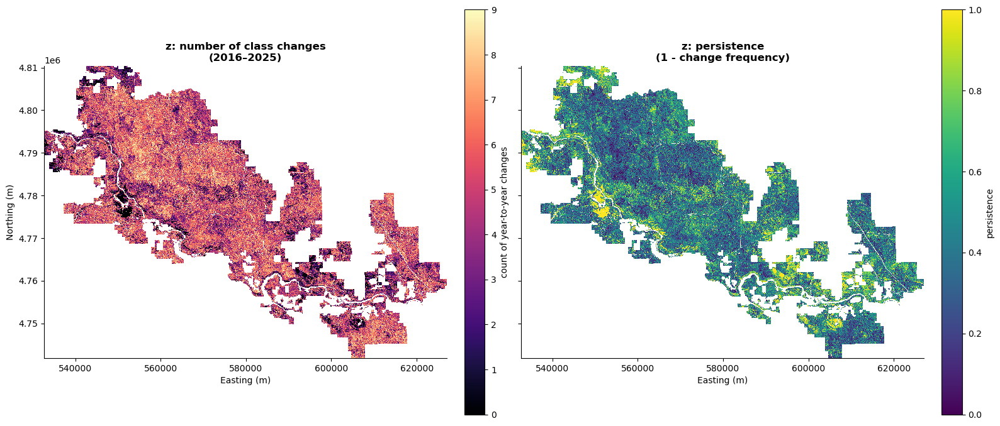


z_plus_polaris temporal stability
Mean persistence:   0.4906
Median persistence: 0.4444


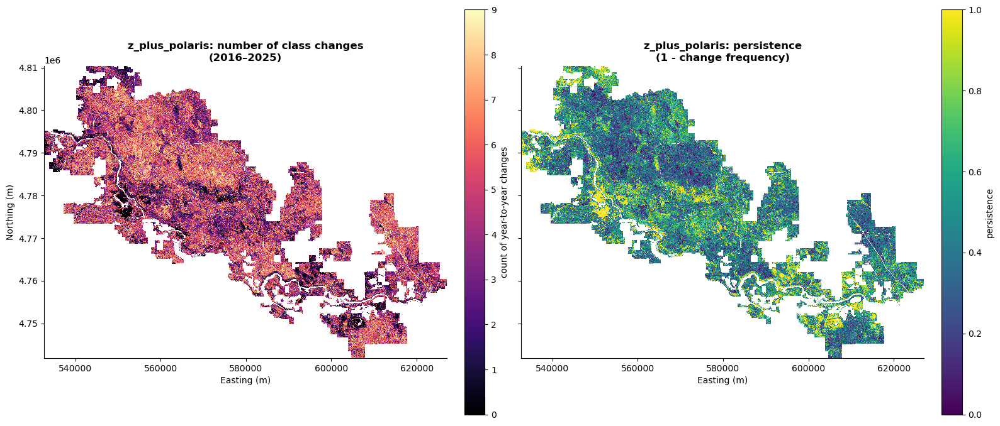


Year-to-year agreement summary:


,representation,year_t,year_t1,n_paired_pixels,exact_agreement
0,z,2016,2017,22004965,0.4445
1,z,2017,2018,22039658,0.4169
2,z,2018,2019,22045691,0.4582
3,z,2019,2020,22054008,0.4910
4,z,2020,2021,22057645,0.5306
5,z,2021,2022,22051623,0.4489
6,z,2022,2023,22055083,0.4575
7,z,2023,2024,22060778,0.3953
8,z,2024,2025,22059770,0.4218
9,z_plus_polaris,2016,2017,22004965,0.4887



Direct z vs z_plus_polaris stability comparison:


representation,year_t,year_t1,z,z_plus_polaris,delta_zplus_minus_z
0,2016,2017,0.4445,0.4887,0.0442
1,2017,2018,0.4169,0.4569,0.0400
2,2018,2019,0.4582,0.4953,0.0371
3,2019,2020,0.4910,0.5255,0.0345
4,2020,2021,0.5306,0.5826,0.0520
5,2021,2022,0.4489,0.4966,0.0477
6,2022,2023,0.4575,0.4947,0.0371
7,2023,2024,0.3953,0.4273,0.0320
8,2024,2025,0.4218,0.4476,0.0258


In [36]:
# =============================================================================
# TEMPORAL STABILITY IN TRUE NCA
# =============================================================================

from rasterio.mask import mask as rio_mask

REPRESENTATIONS_FOR_STABILITY = [
    "z",
    "z_plus_polaris",
]

SAVE_STABILITY_FIGURES = True

STABILITY_FIG_DIR = (
    OUTPUT_DIR
    / "TrueNCA_Stability_Figures"
)
STABILITY_FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

def read_clipped_class_only(
    representation,
    year,
):
    src_path = class_raster_path_local(
        representation,
        year,
    )

    with rasterio.open(
        src_path
    ) as src:
        arr, transform = rio_mask(
            src,
            nca_shapes,
            crop=True,
            filled=True,
            nodata=0,
            all_touched=False,
        )

    return arr[0], transform


stability_records = []

for representation in REPRESENTATIONS_FOR_STABILITY:

    yearly_arrays = []
    transforms = []

    for year in YEARS_TO_MAP:
        arr, transform = read_clipped_class_only(
            representation,
            year,
        )
        yearly_arrays.append(
            arr
        )
        transforms.append(
            transform
        )

    # Basic transform consistency check
    first_transform = transforms[0]
    for t in transforms[1:]:
        if t != first_transform:
            raise ValueError(
                f"Transform mismatch in {representation}"
            )

    stack = np.stack(
        yearly_arrays,
        axis=0,
    )  # [year, row, col]

    valid_stack = np.isin(
        stack,
        VEG_PARENT_CODES,
    )

    # Pairwise year-to-year agreement
    for i in range(
        len(YEARS_TO_MAP) - 1
    ):
        y0 = YEARS_TO_MAP[i]
        y1 = YEARS_TO_MAP[i + 1]

        a = stack[i]
        b = stack[i + 1]

        valid_pair = (
            valid_stack[i]
            & valid_stack[i + 1]
        )

        if valid_pair.sum() == 0:
            agreement = np.nan
        else:
            agreement = np.mean(
                a[valid_pair] == b[valid_pair]
            )

        stability_records.append(
            {
                "representation": representation,
                "year_t": y0,
                "year_t1": y1,
                "n_paired_pixels": int(
                    valid_pair.sum()
                ),
                "exact_agreement": float(
                    agreement
                ),
            }
        )

    # Total number of changes per pixel across the time series
    n_changes = np.zeros(
        stack.shape[1:],
        dtype=np.uint8,
    )
    n_valid_transitions = np.zeros(
        stack.shape[1:],
        dtype=np.uint8,
    )

    for i in range(
        len(YEARS_TO_MAP) - 1
    ):
        valid_pair = (
            valid_stack[i]
            & valid_stack[i + 1]
        )
        changed = (
            stack[i] != stack[i + 1]
        ) & valid_pair

        n_changes += changed.astype(
            np.uint8
        )
        n_valid_transitions += valid_pair.astype(
            np.uint8
        )

    persistence = np.full(
        stack.shape[1:],
        np.nan,
        dtype=np.float64,
    )

    good = n_valid_transitions > 0
    persistence[good] = 1.0 - (
        n_changes[good]
        / n_valid_transitions[good]
    )

    mean_persistence = np.nanmean(
        persistence
    )
    median_persistence = np.nanmedian(
        persistence
    )

    print("\n" + "=" * 90)
    print(f"{representation} temporal stability")
    print("=" * 90)
    print(
        f"Mean persistence:   {mean_persistence:.4f}"
    )
    print(
        f"Median persistence: {median_persistence:.4f}"
    )

    # Plot n_changes and persistence
    bounds_left = first_transform.c
    bounds_top = first_transform.f
    bounds_right = (
        first_transform.c
        + first_transform.a * stack.shape[2]
    )
    bounds_bottom = (
        first_transform.f
        + first_transform.e * stack.shape[1]
    )

    extent = [
        bounds_left,
        bounds_right,
        bounds_bottom,
        bounds_top,
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 7),
        sharex=True,
        sharey=True,
    )

    im0 = axes[0].imshow(
        np.ma.masked_where(
            n_valid_transitions == 0,
            n_changes,
        ),
        cmap="magma",
        extent=extent,
        interpolation="nearest",
    )
    axes[0].set_title(
        f"{representation}: number of class changes\n(2016–2025)",
        fontweight="bold",
    )
    cbar0 = fig.colorbar(
        im0,
        ax=axes[0],
        fraction=0.046,
        pad=0.04,
    )
    cbar0.set_label(
        "count of year-to-year changes"
    )

    im1 = axes[1].imshow(
        np.ma.masked_invalid(
            persistence
        ),
        cmap="viridis",
        vmin=0,
        vmax=1,
        extent=extent,
        interpolation="nearest",
    )
    axes[1].set_title(
        f"{representation}: persistence\n(1 - change frequency)",
        fontweight="bold",
    )
    cbar1 = fig.colorbar(
        im1,
        ax=axes[1],
        fraction=0.046,
        pad=0.04,
    )
    cbar1.set_label(
        "persistence"
    )

    for ax in axes:
        ax.set_xlabel(
            "Easting (m)"
        )
        ax.spines["top"].set_visible(
            False
        )
        ax.spines["right"].set_visible(
            False
        )

    axes[0].set_ylabel(
        "Northing (m)"
    )

    fig.tight_layout()

    if SAVE_STABILITY_FIGURES:
        fig.savefig(
            STABILITY_FIG_DIR
            / f"{representation}_trueNCA_stability.png",
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)

stability_df = pd.DataFrame(
    stability_records
)

stability_df.to_csv(
    STABILITY_FIG_DIR
    / "trueNCA_year_to_year_agreement.csv",
    index=False,
)

print("\nYear-to-year agreement summary:")
display(
    stability_df.round(4)
)

# Optional direct comparison table
stability_wide = stability_df.pivot_table(
    index=["year_t", "year_t1"],
    columns="representation",
    values="exact_agreement",
).reset_index()

if (
    "z" in stability_wide.columns
    and "z_plus_polaris" in stability_wide.columns
):
    stability_wide["delta_zplus_minus_z"] = (
        stability_wide["z_plus_polaris"]
        - stability_wide["z"]
    )

stability_wide.to_csv(
    STABILITY_FIG_DIR
    / "trueNCA_year_to_year_agreement_wide.csv",
    index=False,
)

print("\nDirect z vs z_plus_polaris stability comparison:")
display(
    stability_wide.round(4)
)

## Interpretation boundary

This is a controlled feature-domain experiment, not a new state definition by
fiat.

The key comparisons are:

1. **Z only vs Z + POLARIS, grouped OOF**  
   Does static edaphic context improve discrimination within the observed
   multi-year domain?

2. **Z only vs Z + POLARIS, LOYO**  
   Does the static ecological-potential domain improve transfer to an unseen
   vegetation year?

3. **POLARIS only**  
   How much of the parent-state structure is recoverable from site potential
   without annual optical evidence?

4. **Confusion structure**  
   Do soils specifically resolve persistent ambiguities such as P3↔P5,
   P4↔P6, or shrub-state confusion?

5. **Map geography**  
   Does Z + POLARIS produce more coherent and ecologically credible spatial
   structure without simply reproducing the static soil-only map?

If Z + POLARIS improves both grouped OOF and LOYO while POLARIS-only remains
meaningfully weaker, that supports the intended interpretation:

\[
\text{annual vegetation expression}
+
\text{static ecological potential}
\rightarrow
\text{operational ecological state}.
\]

If the state label is ultimately defined using POLARIS, those same POLARIS
variables should not later be presented as independent explanatory evidence
for why the derived state exists; the edaphic information is already encoded
in the state assignment.
